In [73]:
"""
Importing all necessary libraries for:
- Deep learning (PyTorch)
- Data handling (torchvision, PIL)
- Numerical operations (numpy)
- Visualization (matplotlib)
- Progress tracking (tqdm)
- Results storage (pandas)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

All libraries imported successfully!
PyTorch version: 2.9.0+cpu
Device: CPU


Download and extract the Mini-ImageNet dataset.

The dataset will be downloaded from the link shared:
https://owncloud.iitd.ac.in/nextcloud/index.php/s/W3dNgKKHBQo4eAN



In [74]:
import urllib.request
import zipfile
import shutil
from pathlib import Path

# Dataset configuration
DATASET_URL = "https://owncloud.iitd.ac.in/nextcloud/index.php/s/W3dNgKKHBQo4eAN/download"
DATASET_DIR = "./mini_imagenet_dataset"  # Local directory to store dataset
DATASET_ZIP = "./mini_imagenet.zip"  # Temporary zip file

In [75]:
def download_dataset(url, save_path):
    """
    Download dataset from URL with progress indication
    """
    print(f"Downloading dataset from: {url}")
    print("This may take several minutes depending on your internet connection...")

    def reporthook(count, block_size, total_size):
        """Progress bar for download"""
        percent = int(count * block_size * 100 / total_size)
        print(f"\rDownload progress: {percent}% ", end='')

    try:
        urllib.request.urlretrieve(url, save_path, reporthook=reporthook)
        print("\n✓ Download completed!")
        return True
    except Exception as e:
        print(f"\n✗ Download failed: {e}")
        return False

def extract_dataset(zip_path, extract_to):
    """
    Extract zip file to specified directory
    """
    print(f"\nExtracting dataset to: {extract_to}")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("✓ Extraction completed!")
        return True
    except Exception as e:
        print(f"✗ Extraction failed: {e}")
        return False

# Check if dataset already exists
if os.path.exists(DATASET_DIR):
    print(f"Dataset directory '{DATASET_DIR}' already exists.")
    print("Skipping download. Delete the directory if you want to re-download.")
else:
    print("="*70)
    print("DATASET DOWNLOAD AND SETUP")
    print("="*70)

    # Download dataset
    if download_dataset(DATASET_URL, DATASET_ZIP):
        # Extract dataset
        if extract_dataset(DATASET_ZIP, DATASET_DIR):
            # Clean up zip file
            print("\nCleaning up...")
            os.remove(DATASET_ZIP)
            print("✓ Temporary files removed")
        else:
            print("Please check the zip file and try again.")
    else:
        print("\n⚠️ Dataset download failed!")
        print("Please manually download from:")
        print("https://owncloud.iitd.ac.in/nextcloud/index.php/s/W3dNgKKHBQo4eAN")
        print(f"And extract to: {DATASET_DIR}")

Dataset directory './mini_imagenet_dataset' already exists.
Skipping download. Delete the directory if you want to re-download.


In [76]:
# Search for train/val/test folders
def find_data_folders(root_dir):
    """
    Recursively search for train, val, test folders
    Returns the parent directory containing these folders
    """
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if 'train' in dirnames and 'val' in dirnames and 'test' in dirnames:
            return dirpath
    return None

DATA_PATH = find_data_folders(DATASET_DIR)

if DATA_PATH is None:
    # If not found in standard structure, check if extracted directly
    if os.path.exists(os.path.join(DATASET_DIR, 'train')):
        DATA_PATH = DATASET_DIR
    else:
        print("⚠️ Could not find train/val/test folders!")
        print("Please check the extracted dataset structure.")
        DATA_PATH = DATASET_DIR

print(f"Dataset base path: {DATA_PATH}")

# Set paths for train, validation, and test sets
TRAIN_PATH = os.path.join(DATA_PATH, 'train')
VAL_PATH = os.path.join(DATA_PATH, 'val')
TEST_PATH = os.path.join(DATA_PATH, 'test')

print("\nDataset paths configured:")
print(f"  Training data: {TRAIN_PATH}")
print(f"  Validation data: {VAL_PATH}")
print(f"  Test data: {TEST_PATH}")

# Verify paths exist
if all([os.path.exists(p) for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]]):
    print("\n✓ All dataset folders found successfully!")
else:
    print("\n⚠️ Warning: Some dataset folders are missing!")
    print("Please verify the dataset structure.")

Dataset base path: ./mini_imagenet_dataset/5

Dataset paths configured:
  Training data: ./mini_imagenet_dataset/5/train
  Validation data: ./mini_imagenet_dataset/5/val
  Test data: ./mini_imagenet_dataset/5/test

✓ All dataset folders found successfully!


Explore and Understand the dataset
- Number of classes
- Number of images per class
- Image dimensions and format
- Sample visualization

In [77]:
def explore_dataset(data_path, split_name):
    """
    Explore dataset structure and statistics

    Args:
        data_path: Path to the dataset split (train/val/test)
        split_name: Name of the split for display
    """
    print(f"\n{'='*60}")
    print(f"Exploring {split_name} Dataset")
    print(f"{'='*60}")

    # Check if path exists
    if not os.path.exists(data_path):
        print(f"⚠️ Warning: Path {data_path} does not exist!")
        print("Please update DATA_PATH in Cell 2")
        return None

    # Get class folders
    classes = sorted([d for d in os.listdir(data_path)
                     if os.path.isdir(os.path.join(data_path, d))])

    print(f"Number of classes: {len(classes)}")
    print(f"Class names (first 5): {classes[:5]}")

    # Count images per class
    class_counts = {}
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        num_images = len([f for f in os.listdir(cls_path)
                         if f.endswith(('.jpg', '.jpeg', '.png', '.JPEG'))])
        class_counts[cls] = num_images

    print(f"\nImages per class:")
    print(f"  Min: {min(class_counts.values())}")
    print(f"  Max: {max(class_counts.values())}")
    print(f"  Mean: {np.mean(list(class_counts.values())):.2f}")
    print(f"  Total images: {sum(class_counts.values())}")

    # Load a sample image to check dimensions
    first_class = classes[0]
    first_class_path = os.path.join(data_path, first_class)
    sample_img_name = os.listdir(first_class_path)[0]
    sample_img_path = os.path.join(first_class_path, sample_img_name)

    sample_img = Image.open(sample_img_path)
    print(f"\nSample image properties:")
    print(f"  Size: {sample_img.size}")
    print(f"  Mode: {sample_img.mode}")
    print(f"  Format: {sample_img.format}")

    return classes

# Explore all splits
train_classes = explore_dataset(TRAIN_PATH, "Training")
val_classes = explore_dataset(VAL_PATH, "Validation")
test_classes = explore_dataset(TEST_PATH, "Test")


Exploring Training Dataset
Number of classes: 33
Class names (first 5): ['african_hunting_dog', 'ant', 'ashcan', 'black_footed_ferret', 'bookshop']

Images per class:
  Min: 400
  Max: 400
  Mean: 400.00
  Total images: 13200

Sample image properties:
  Size: (84, 84)
  Mode: RGB
  Format: JPEG

Exploring Validation Dataset
Number of classes: 33
Class names (first 5): ['african_hunting_dog', 'ant', 'ashcan', 'black_footed_ferret', 'bookshop']

Images per class:
  Min: 100
  Max: 100
  Mean: 100.00
  Total images: 3300

Sample image properties:
  Size: (84, 84)
  Mode: RGB
  Format: JPEG

Exploring Test Dataset
Number of classes: 33
Class names (first 5): ['african_hunting_dog', 'ant', 'ashcan', 'black_footed_ferret', 'bookshop']

Images per class:
  Min: 100
  Max: 100
  Mean: 100.00
  Total images: 3300

Sample image properties:
  Size: (84, 84)
  Mode: RGB
  Format: JPEG


Visualize sample images from different classes to understand:
- Image quality and content
- Class diversity
- Any data issues

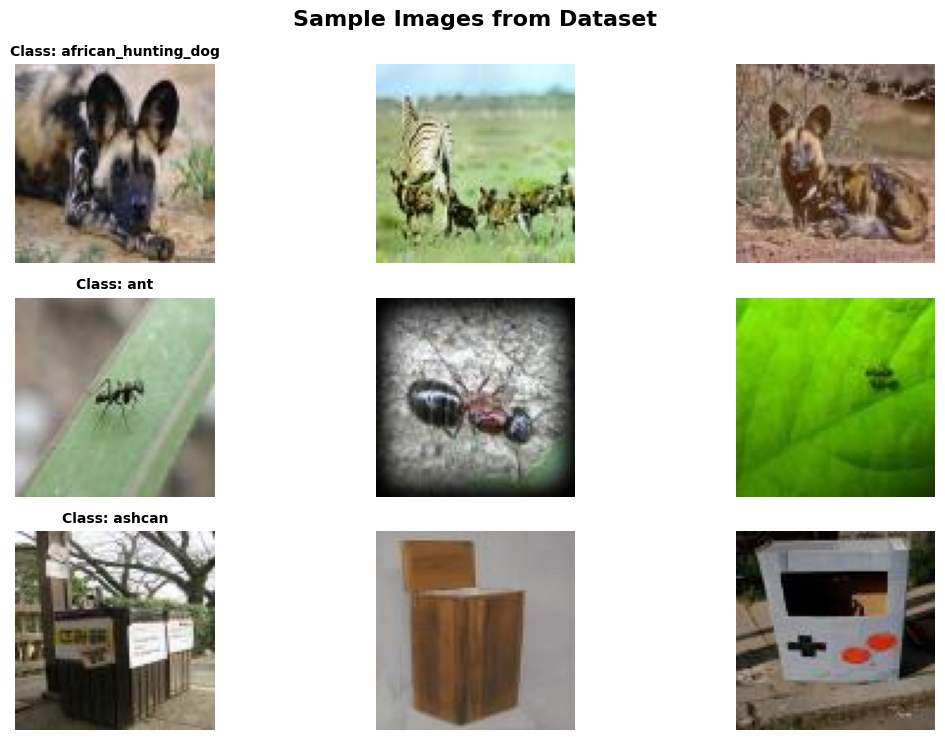

In [78]:

def visualize_samples(data_path, classes, num_classes=3, images_per_class=3):
    """
    Display sample images from multiple classes

    Args:
        data_path: Path to dataset split
        classes: List of class names
        num_classes: Number of classes to show
        images_per_class: Number of images per class to display
    """
    if not os.path.exists(data_path):
        print("Dataset path not found. Please update DATA_PATH.")
        return

    fig, axes = plt.subplots(num_classes, images_per_class,
                            figsize=(12, num_classes*2.5))
    fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

    for i, cls in enumerate(classes[:num_classes]):
        cls_path = os.path.join(data_path, cls)
        img_files = [f for f in os.listdir(cls_path)
                    if f.endswith(('.jpg', '.jpeg', '.png', '.JPEG'))]

        for j in range(images_per_class):
            img_path = os.path.join(cls_path, img_files[j])
            img = Image.open(img_path)

            ax = axes[i, j] if num_classes > 1 else axes[j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Class: {cls}', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Visualize samples from training set
if train_classes:
    visualize_samples(TRAIN_PATH, train_classes)

Its a very versatile dataset holding images from various types.


DEFINE DATA FOR TRANSFORMATION

In [79]:
# Mean and std for Mini-ImageNet (calculated from dataset)
# Using ImageNet statistics as approximation
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Training transformations with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((84, 84)),  # Ensure consistent size
    transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip horizontally
    transforms.RandomRotation(degrees=15),  # Rotate up to ±15 degrees
    transforms.ToTensor(),  # Convert PIL Image to tensor [0, 1]
    transforms.Normalize(mean=MEAN, std=STD)  # Normalize to mean=0, std=1
])

# Validation/Test transformations (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((84, 84)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("Data transformations defined:")
print("\nTraining transforms (with augmentation):")
print("  - Resize to 84×84")
print("  - Random horizontal flip (p=0.5)")
print("  - Random rotation (±15°)")
print("  - Convert to tensor")
print("  - Normalize")

print("\nTest/Val transforms (no augmentation):")
print("  - Resize to 84×84")
print("  - Convert to tensor")
print("  - Normalize")

Data transformations defined:

Training transforms (with augmentation):
  - Resize to 84×84
  - Random horizontal flip (p=0.5)
  - Random rotation (±15°)
  - Convert to tensor
  - Normalize

Test/Val transforms (no augmentation):
  - Resize to 84×84
  - Convert to tensor
  - Normalize


Create PyTorch Datasets and DataLoaders

In [80]:
BATCH_SIZE = 32  # Adjust based on your CPU memory

In [81]:
def create_dataloaders(train_path, val_path, test_path, batch_size=32):
    """
    Create PyTorch datasets and dataloaders

    Returns:
        train_loader, val_loader, test_loader, num_classes
    """
    # Check if paths exist
    if not all([os.path.exists(p) for p in [train_path, val_path, test_path]]):
        print("⚠️ Dataset paths not found! Please update DATA_PATH in Cell 2")
        return None, None, None, 0

    # Create datasets using ImageFolder
    # ImageFolder automatically assigns labels based on folder names
    train_dataset = ImageFolder(root=train_path, transform=train_transform)
    val_dataset = ImageFolder(root=val_path, transform=test_transform)
    test_dataset = ImageFolder(root=test_path, transform=test_transform)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,  # Shuffle training data each epoch
        num_workers=2,  # Parallel data loading (adjust based on CPU cores)
        pin_memory=False  # Set to True if using GPU
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,  # Don't shuffle validation data
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  # Don't shuffle test data
        num_workers=2
    )

    num_classes = len(train_dataset.classes)

    print(f"Datasets created successfully!")
    print(f"\nDataset sizes:")
    print(f"  Training: {len(train_dataset)} images")
    print(f"  Validation: {len(val_dataset)} images")
    print(f"  Test: {len(test_dataset)} images")
    print(f"  Number of classes: {num_classes}")
    print(f"  Batch size: {batch_size}")
    print(f"  Training batches per epoch: {len(train_loader)}")

    return train_loader, val_loader, test_loader, num_classes, train_dataset.classes

In [82]:
# Create dataloaders
train_loader, val_loader, test_loader, num_classes, class_names = create_dataloaders(
    TRAIN_PATH, VAL_PATH, TEST_PATH, BATCH_SIZE
)

Datasets created successfully!

Dataset sizes:
  Training: 13200 images
  Validation: 3300 images
  Test: 3300 images
  Number of classes: 33
  Batch size: 32
  Training batches per epoch: 413


DEFINE CNN MODEL ARCHITECTURE

In [83]:
class FlexibleCNN(nn.Module):
    def __init__(self, num_classes, config):
        """
        Flexible CNN architecture

        Args:
            num_classes: Number of output classes
            config: Dictionary with architecture parameters
                - conv_layers: List of filter counts [64, 128, 256]
                - kernel_size: Conv kernel size (default 3)
                - stride: Conv stride (default 1)
                - pool_size: MaxPool kernel size (default 2)
                - pool_stride: MaxPool stride (default 2)
                - fc_layers: List of FC layer sizes [512, 256]
                - dropout: Dropout probability (default 0.5)
        """
        super(FlexibleCNN, self).__init__()

        self.config = config
        conv_filters = config.get('conv_layers', [64, 128, 256])
        kernel_size = config.get('kernel_size', 3)
        conv_stride = config.get('stride', 1)  # Extract conv stride from config
        pool_size = config.get('pool_size', 2)
        pool_stride = config.get('pool_stride', 2)
        fc_sizes = config.get('fc_layers', [512])
        dropout_prob = config.get('dropout', 0.5)

        # Build convolutional layers dynamically
        self.conv_layers = nn.ModuleList()
        in_channels = 3  # RGB images

        for idx, out_channels in enumerate(conv_filters):
            # Build conv block with conditional pooling
            layers = [
                nn.Conv2d(in_channels, out_channels,
                         kernel_size=kernel_size,
                         stride=conv_stride,
                         padding=kernel_size//2),
                nn.BatchNorm2d(out_channels),  # Normalize activations
                nn.ReLU(inplace=True)
            ]

            # Only add MaxPool if pool_size > 1
            if pool_size > 1:
                layers.append(nn.MaxPool2d(kernel_size=pool_size, stride=pool_stride))
                print(f"  Conv block {idx+1}: Added MaxPool2d(kernel_size={pool_size}, stride={pool_stride})")
            else:
                print(f"  Conv block {idx+1}: No pooling (pool_size={pool_size})")

            self.conv_layers.append(nn.Sequential(*layers))
            in_channels = out_channels

        # Calculate size after conv layers
        # Account for BOTH conv stride AND pool stride
        # Starting size: 84x84
        size_after_conv = 84
        print(f"  Initial size: {size_after_conv}×{size_after_conv}")

        for idx, _ in enumerate(conv_filters):
            # Conv2d with stride and padding affects spatial dimensions
            # Formula: output_size = (input_size + 2*padding - kernel_size) // stride + 1
            padding = kernel_size // 2
            size_after_conv = (size_after_conv + 2 * padding - kernel_size) // conv_stride + 1
            print(f"  After Conv{idx+1} (stride={conv_stride}, padding={padding}): {size_after_conv}×{size_after_conv}")

            # Then apply pooling if pool_size > 1
            if pool_size > 1:
                size_after_conv = size_after_conv // pool_stride
                print(f"  After Pool{idx+1} (pool_size={pool_size}, stride={pool_stride}): {size_after_conv}×{size_after_conv}")
            else:
                print(f"  No pooling (pool_size={pool_size}, keeping size={size_after_conv}×{size_after_conv})")

        flattened_size = conv_filters[-1] * size_after_conv * size_after_conv

        # Summary output
        print(f"  Final spatial size: {size_after_conv}×{size_after_conv}")
        print(f"  Flattened size: {conv_filters[-1]} × {size_after_conv} × {size_after_conv} = {flattened_size:,}")

        # Build fully connected layers dynamically
        self.fc_layers = nn.ModuleList()
        in_features = flattened_size

        for fc_size in fc_sizes:
            # Build FC layer with optional dropout
            if dropout_prob > 0:
                # Include dropout if probability > 0
                self.fc_layers.append(
                    nn.Sequential(
                        nn.Linear(in_features, fc_size),
                        nn.ReLU(inplace=True),
                        nn.Dropout(dropout_prob)
                    )
                )
            else:
                # No dropout when dropout_prob = 0
                self.fc_layers.append(
                    nn.Sequential(
                        nn.Linear(in_features, fc_size),
                        nn.ReLU(inplace=True)
                    )
                )
            in_features = fc_size

        # Final classification layer
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        """
        Forward pass through the network

        Args:
            x: Input tensor [batch_size, 3, 84, 84]

        Returns:
            Output logits [batch_size, num_classes]
        """
        # Pass through convolutional layers
        for conv_layer in self.conv_layers:
            x = conv_layer(x)

        # Flatten for fully connected layers
        x = x.view(x.size(0), -1)  # [batch_size, flattened_features]

        # Pass through fully connected layers
        for fc_layer in self.fc_layers:
            x = fc_layer(x)

        # Final classification
        x = self.classifier(x)

        return x

In [84]:
print("Flexible CNN architecture defined!")
print("\nExample configuration:")
example_config = {
    'conv_layers': [64, 128, 256],
    'kernel_size': 3,
    'stride': 1,
    'pool_size': 2,
    'pool_stride': 2,
    'fc_layers': [512, 256],
    'dropout': 0.5
}
print(example_config)

Flexible CNN architecture defined!

Example configuration:
{'conv_layers': [64, 128, 256], 'kernel_size': 3, 'stride': 1, 'pool_size': 2, 'pool_stride': 2, 'fc_layers': [512, 256], 'dropout': 0.5}


TRAINING AND EVALUATION FUNCTIONS

In [85]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train model for one epoch

    Returns:
        Average loss and accuracy for the epoch
    """
    model.train()  # Set model to training mode (enables dropout, etc.)

    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for training
    pbar = tqdm(train_loader, desc='Training', leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Zero gradients from previous iteration
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights

        # Calculate statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [86]:
def evaluate(model, data_loader, criterion, device):
    """
    Evaluate model on validation/test set

    Returns:
        Average loss and accuracy
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Don't compute gradients (saves memory and time)
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calculate statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / total
    accuracy = 100. * correct / total

    return avg_loss, accuracy

In [87]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device, model_name="Model"):
    """
    Complete training loop with validation

    Returns:
        Dictionary with training history
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                           optimizer, device)

        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print epoch results
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            print(f"✓ New best validation accuracy!")

    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time:.2f} seconds")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

    return history, best_val_acc

Define 10 Experimental Configurations

In [88]:
# Configuration dictionary for all experiments
# Each configuration is numbered and has a descriptive name

configurations = {

    # CONFIG 1: shallow network
    'config_1': {
        'name': 'Shallow (1 Conv layer only)',
        'conv_layers': [64],
        'kernel_size': 3,
        'stride': 1,
        'pool_size': 2,
        'pool_stride': 2,
        'fc_layers': [128],
        'dropout': 0,
        'epochs': 5,
        'lr': 0.001
    },

    # CONFIG 2: BASELINE - 2 Conv 1 FC With less Dropout
    'config_2': {
        'name': 'Baseline (2 Conv, 1 FC) With less Dropout',
        'conv_layers': [32, 64],
        'kernel_size': 3,
        'stride': 1,
        'pool_size': 2,
        'pool_stride': 2,
        'fc_layers': [128],
        'dropout': 0.1,
        'epochs': 5,
        'lr': 0.001
    },

    # CONFIG 3: BASELINE - 2 Conv 1 FC With Dropout
    'config_3': {
        'name': 'Baseline (2 Conv, 1 FC)',
        'conv_layers': [32, 64],
        'kernel_size': 3,
        'stride': 1,
        'pool_size': 2,
        'pool_stride': 2,
        'fc_layers': [128],
        'dropout': 0.3,
        'epochs': 5,
        'lr': 0.001
    },

    # CONFIG 4: Different pooling strategy
    'config_4': {
        'name': 'No Pooling After Each Conv',
        'conv_layers': [32, 64],
        'kernel_size': 3,
        'stride': 2,  # Use stride instead of pooling
        'pool_size': 1,  # No pooling
        'pool_stride': 1,
        'fc_layers': [128],
        'dropout': 0.3,
        'epochs': 5,
        'lr': 0.001
    },

    # CONFIG 5: More FC layers
    'config_5': {
        'name': 'Multiple FC Layers',
        'conv_layers': [32, 64],
        'kernel_size': 3,
        'stride': 1,
        'pool_size': 2,
        'pool_stride': 2,
        'fc_layers': [256, 128],  # Two FC layers
        'dropout': 0.3,
        'epochs': 5,
        'lr': 0.001
    },

    # CONFIG 6: Deep Network with More FC Layers
    'config_6': {
        'name': 'Balanced Architecture',
        'conv_layers': [64, 128, 256],  # Good depth
        'kernel_size': 3,
        'stride': 1,
        'pool_size': 2,
        'pool_stride': 2,
        'fc_layers': [512, 256],  # Good capacity
        'dropout': 0.3,
        'epochs': 5,
        'lr': 0.001
    }

}

In [89]:
print("6 Experimental Configurations Defined:")
print("="*60)
for config_id, config in configurations.items():
    print(f"\n{config_id.upper()}: {config['name']}")
    print(f"  Conv layers: {config['conv_layers']}")
    print(f"  FC layers: {config['fc_layers']}")
    print(f"  Stride: {config['stride']}, Pooling: {config['pool_size']}")
    print(f"  Epochs: {config['epochs']}")

6 Experimental Configurations Defined:

CONFIG_1: Shallow (1 Conv layer only)
  Conv layers: [64]
  FC layers: [128]
  Stride: 1, Pooling: 2
  Epochs: 5

CONFIG_2: Baseline (2 Conv, 1 FC) With less Dropout
  Conv layers: [32, 64]
  FC layers: [128]
  Stride: 1, Pooling: 2
  Epochs: 5

CONFIG_3: Baseline (2 Conv, 1 FC)
  Conv layers: [32, 64]
  FC layers: [128]
  Stride: 1, Pooling: 2
  Epochs: 5

CONFIG_4: No Pooling After Each Conv
  Conv layers: [32, 64]
  FC layers: [128]
  Stride: 2, Pooling: 1
  Epochs: 5

CONFIG_5: Multiple FC Layers
  Conv layers: [32, 64]
  FC layers: [256, 128]
  Stride: 1, Pooling: 2
  Epochs: 5

CONFIG_6: Balanced Architecture
  Conv layers: [64, 128, 256]
  FC layers: [512, 256]
  Stride: 1, Pooling: 2
  Epochs: 5


RUN ALL EXPERIMENTS

In [90]:
# Storage for all results
all_results = []
all_histories = {}
device = torch.device('cpu')

# Check if dataloaders were created successfully
if train_loader is None:
    print("⚠️ Please update DATA_PATH and run previous cells first!")
else:
    print("Starting experiments...")
    print(f"Training on: {device}")
    print(f"Total configurations: {len(configurations)}\n")

    for config_id, config in configurations.items():
        print(f"\n{'#'*70}")
        print(f"# EXPERIMENT: {config_id.upper()}")
        print(f"# {config['name']}")
        print(f"{'#'*70}")

        # Create model
        model = FlexibleCNN(num_classes=num_classes, config=config).to(device)

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\nModel Architecture:")
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")

        # Define loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])

        # Train model
        history, best_val_acc = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=config['epochs'],
            device=device,
            model_name=config['name']
        )

        # Evaluate on test set
        print("\nEvaluating on test set...")
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

        # Store results
        result = {
            'Config ID': config_id,
            'Name': config['name'],
            'Conv Layers': str(config['conv_layers']),
            'FC Layers': str(config['fc_layers']),
            'Stride': config['stride'],
            'Pool Size': config['pool_size'],
            'Epochs': config['epochs'],
            'Total Params': total_params,
            'Best Val Acc': f"{best_val_acc:.2f}%",
            'Test Acc': f"{test_acc:.2f}%",
            'Final Train Acc': f"{history['train_acc'][-1]:.2f}%",
            'Final Val Acc': f"{history['val_acc'][-1]:.2f}%"
        }

        all_results.append(result)
        all_histories[config_id] = history

        print(f"\n✓ {config_id} completed!")
        print("-" * 70)

    print("\n" + "="*70)
    print("ALL EXPERIMENTS COMPLETED!")
    print("="*70)

Starting experiments...
Training on: cpu
Total configurations: 6


######################################################################
# EXPERIMENT: CONFIG_1
# Shallow (1 Conv layer only)
######################################################################
  Conv block 1: Added MaxPool2d(kernel_size=2, stride=2)
  Initial size: 84×84
  After Conv1 (stride=1, padding=1): 84×84
  After Pool1 (pool_size=2, stride=2): 42×42
  Final spatial size: 42×42
  Flattened size: 64 × 42 × 42 = 112,896

Model Architecture:
  Total parameters: 14,456,993
  Trainable parameters: 14,456,993

Training Shallow (1 Conv layer only)

Epoch 1/5
----------------------------------------


Train Loss: 4.2073 | Train Acc: 3.34%
Val Loss: 3.4975 | Val Acc: 3.03%
✓ New best validation accuracy!

Epoch 2/5
----------------------------------------


Train Loss: 3.4984 | Train Acc: 3.23%
Val Loss: 3.4969 | Val Acc: 3.03%

Epoch 3/5
----------------------------------------


Train Loss: 3.4972 | Train Acc: 2.94%
Val Loss: 3.4965 | Val Acc: 3.06%
✓ New best validation accuracy!

Epoch 4/5
----------------------------------------


Train Loss: 3.4947 | Train Acc: 2.96%
Val Loss: 3.4966 | Val Acc: 3.03%

Epoch 5/5
----------------------------------------


...

Train Loss: 3.2608 | Train Acc: 11.80%
Val Loss: 2.8317 | Val Acc: 20.91%
✓ New best validation accuracy!

Epoch 2/5
----------------------------------------


Train Loss: 2.9030 | Train Acc: 18.73%
Val Loss: 2.6040 | Val Acc: 27.58%
✓ New best validation accuracy!

Epoch 3/5
----------------------------------------


Train Loss: 2.7250 | Train Acc: 23.66%
Val Loss: 2.5107 | Val Acc: 29.15%
✓ New best validation accuracy!

Epoch 4/5
----------------------------------------


Train Loss: 2.5466 | Train Acc: 27.55%
Val Loss: 2.3123 | Val Acc: 34.30%
✓ New best validation accuracy!

Epoch 5/5
----------------------------------------


Train Loss: 2.4246 | Train Acc: 30.61%
Val Loss: 2.1685 | Val Acc: 40.36%
✓ New best validation accuracy!

Training completed in 3695.59 seconds
Best validation accuracy: 40.36%

Evaluating on test set...
Test Loss: 2.1943 | Test Acc: 39.70%

✓ config_6 completed!
----------------------------------------------------------------------

ALL EXPERIMENTS COMPLETED!


RESULTS TABLE

In [91]:
# Create DataFrame for better visualization
results_df = pd.DataFrame(all_results)

print("PART A: EXPERIMENTAL RESULTS TABLE")
print("="*100)
print()

# Display full table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(results_df.to_string(index=False))
print()

# Save to CSV for report
results_df.to_csv('part_a_results.csv', index=False)
print("✓ Results saved to 'part_a_results.csv'")

PART A: EXPERIMENTAL RESULTS TABLE

Config ID                                      Name    Conv Layers  FC Layers  Stride  Pool Size  Epochs  Total Params Best Val Acc Test Acc Final Train Acc Final Val Acc
 config_1               Shallow (1 Conv layer only)           [64]      [128]       1          2       5      14456993        3.06%    3.03%           2.75%         3.03%
 config_2 Baseline (2 Conv, 1 FC) With less Dropout       [32, 64]      [128]       1          2       5       3636641        3.06%    3.03%           2.45%         3.03%
 config_3                   Baseline (2 Conv, 1 FC)       [32, 64]      [128]       1          2       5       3636641       15.67%   14.15%          11.65%        15.12%
 config_4                No Pooling After Each Conv       [32, 64]      [128]       2          1       5       3636641       13.94%   14.09%           9.35%        13.94%
 config_5                        Multiple FC Layers       [32, 64] [256, 128]       1          2       5     

VISUALIZE TRAINING CURVES

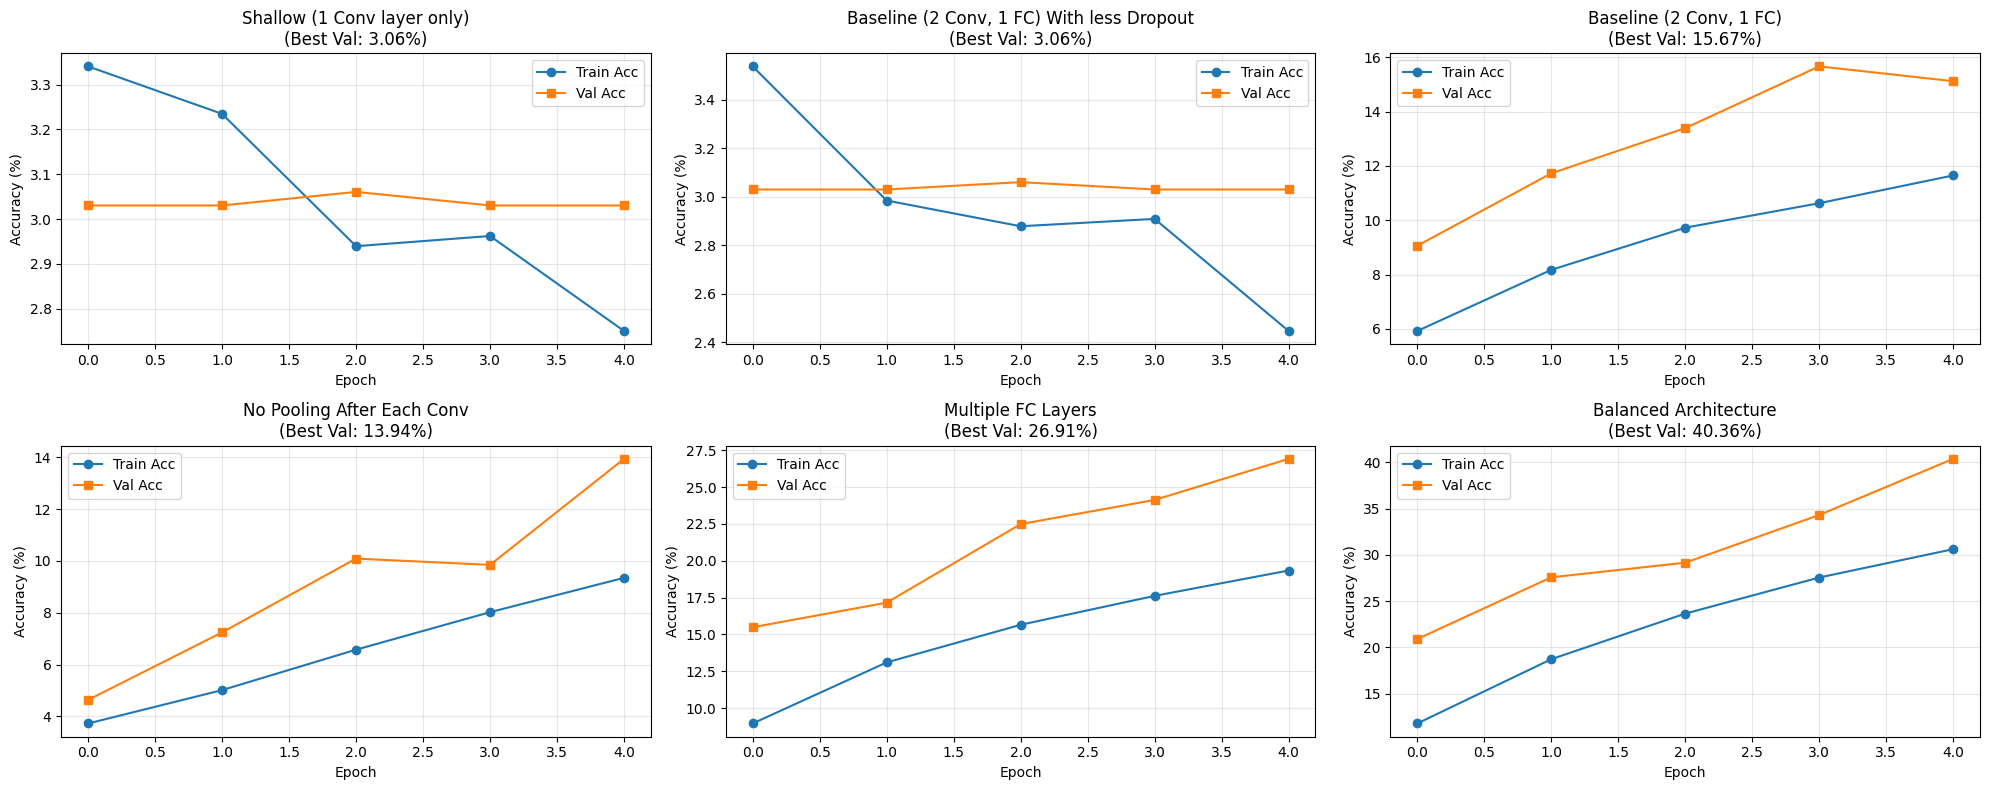

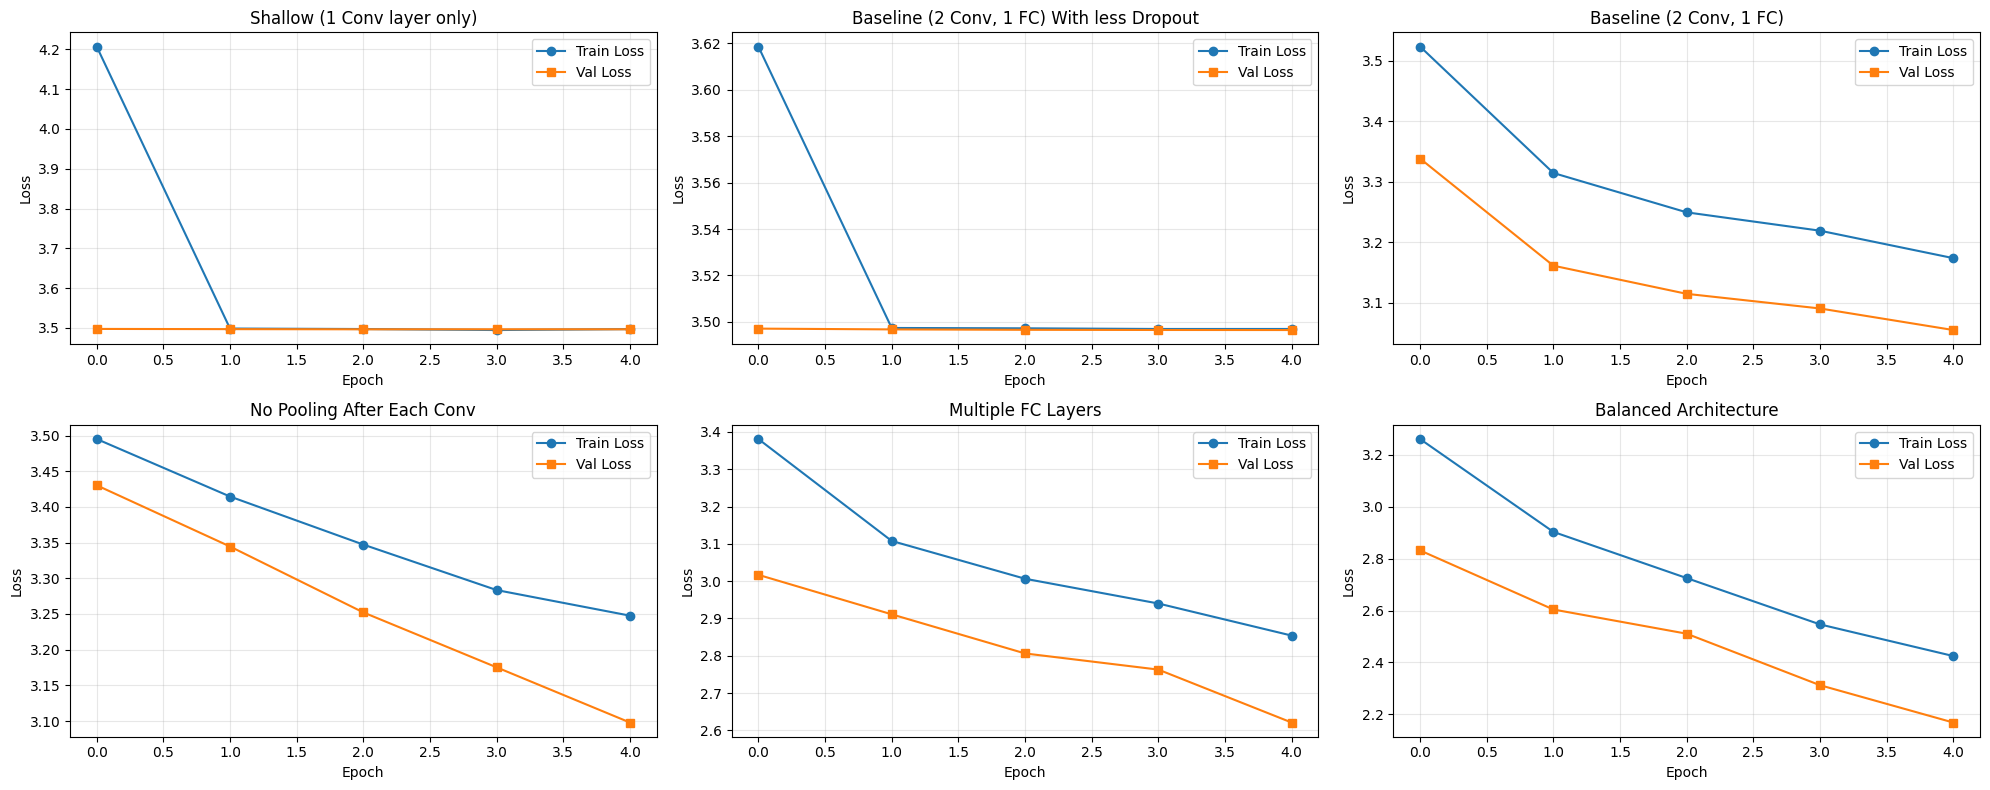

✓ Training curves saved


In [107]:
def plot_training_curves(histories, configurations, metric='acc'):
    """
    Plot training curves for all configurations

    Args:
        histories: Dictionary of training histories
        configurations: Configuration dictionary
        metric: 'acc' or 'loss'
    """
    fig, axes = plt.subplots(2, 3, figsize=(20, 8))
    axes = axes.flatten()

    for idx, (config_id, history) in enumerate(histories.items()):
        ax = axes[idx]

        if metric == 'acc':
            ax.plot(history['train_acc'], label='Train Acc', marker='o')
            ax.plot(history['val_acc'], label='Val Acc', marker='s')
            ax.set_ylabel('Accuracy (%)')
            ax.set_title(f"{configurations[config_id]['name']}\n(Best Val: {max(history['val_acc']):.2f}%)")
        else:
            ax.plot(history['train_loss'], label='Train Loss', marker='o')
            ax.plot(history['val_loss'], label='Val Loss', marker='s')
            ax.set_ylabel('Loss')
            ax.set_title(f"{configurations[config_id]['name']}")

        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'part_a_training_curves_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot accuracy curves
if all_histories:
    plot_training_curves(all_histories, configurations, metric='acc')
    plot_training_curves(all_histories, configurations, metric='loss')
    print("✓ Training curves saved")

PERFORMANCE ANALYSIS AND COMPARISON

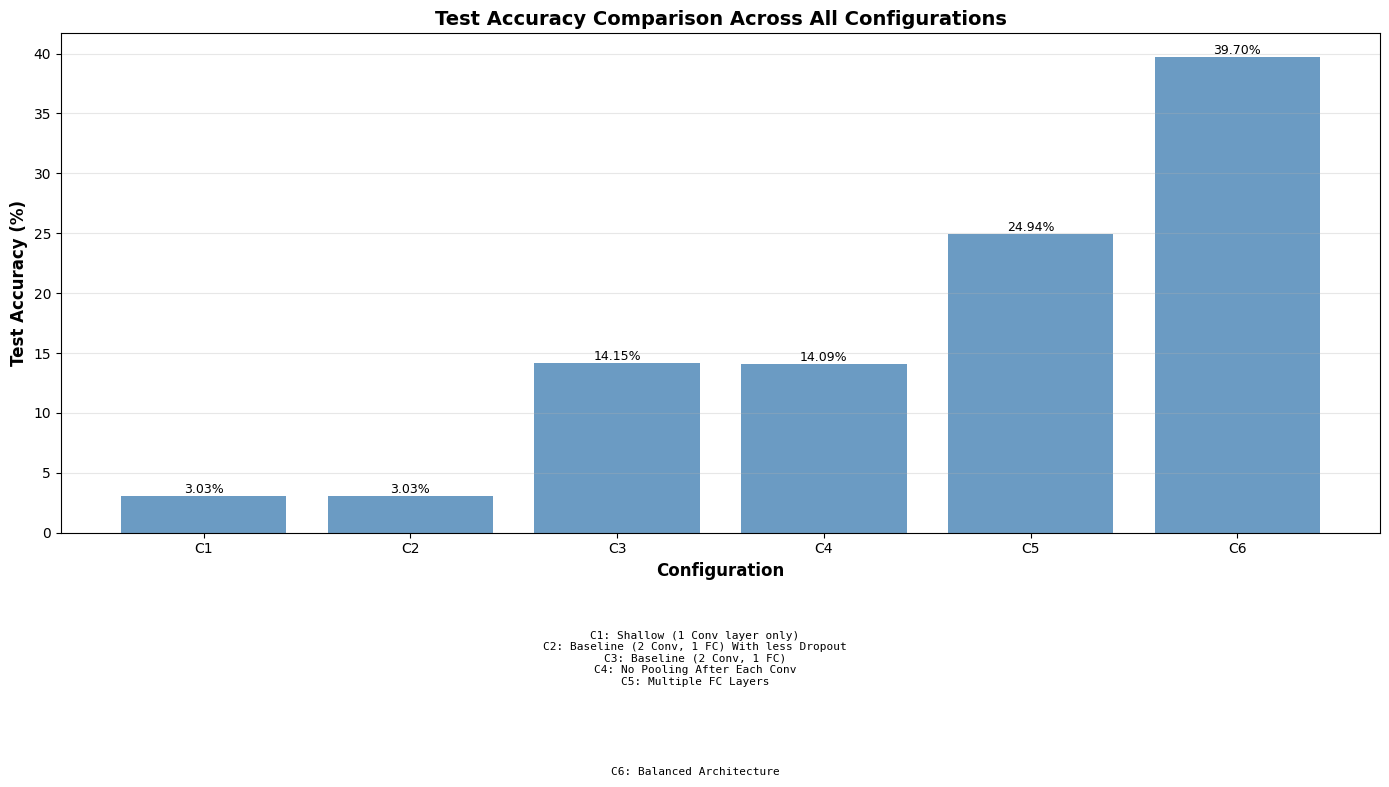


PERFORMANCE ANALYSIS

🏆 BEST Configuration:
   Balanced Architecture
   Test Accuracy: 39.70%
   Config: [64, 128, 256]
   FC Layers: [512, 256]

📉 WORST Configuration:
   Shallow (1 Conv layer only)
   Test Accuracy: 3.03%

📊 Statistics:
   Mean Test Accuracy: 16.49%
   Std Dev: 12.80%
   Range: 36.67%


In [93]:
"""
Analyze results to understand:
1. Which parameters had the biggest impact?
2. Where does performance plateau?
3. Signs of overfitting or underfitting?
"""

if all_results:
    # Extract test accuracies (remove % sign and convert to float)
    test_accs = [float(r['Test Acc'].replace('%', '')) for r in all_results]
    config_names = [r['Name'] for r in all_results]

    # Create bar chart comparing test accuracies
    plt.figure(figsize=(14, 6))
    bars = plt.bar(range(len(config_names)), test_accs, color='steelblue', alpha=0.8)
    plt.xlabel('Configuration', fontsize=12, fontweight='bold')
    plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    plt.title('Test Accuracy Comparison Across All Configurations',
              fontsize=14, fontweight='bold')
    plt.xticks(range(len(config_names)),
               [f"C{i+1}" for i in range(len(config_names))],
               rotation=0)
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for idx, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{test_accs[idx]:.2f}%',
                ha='center', va='bottom', fontsize=9)

    # Add legend showing config names
    legend_labels = [f"C{i+1}: {name}" for i, name in enumerate(config_names)]
    plt.figtext(0.5, -0.15, '\n'.join(legend_labels[:5]),
                ha='center', fontsize=8, family='monospace')
    plt.figtext(0.5, -0.30, '\n'.join(legend_labels[5:]),
                ha='center', fontsize=8, family='monospace')

    plt.tight_layout()
    plt.savefig('part_a_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Find best and worst
    best_idx = test_accs.index(max(test_accs))
    worst_idx = test_accs.index(min(test_accs))

    print("\n" + "="*70)
    print("PERFORMANCE ANALYSIS")
    print("="*70)
    print(f"\n🏆 BEST Configuration:")
    print(f"   {config_names[best_idx]}")
    print(f"   Test Accuracy: {test_accs[best_idx]:.2f}%")
    print(f"   Config: {all_results[best_idx]['Conv Layers']}")
    print(f"   FC Layers: {all_results[best_idx]['FC Layers']}")

    print(f"\n📉 WORST Configuration:")
    print(f"   {config_names[worst_idx]}")
    print(f"   Test Accuracy: {test_accs[worst_idx]:.2f}%")

    print(f"\n📊 Statistics:")
    print(f"   Mean Test Accuracy: {np.mean(test_accs):.2f}%")
    print(f"   Std Dev: {np.std(test_accs):.2f}%")
    print(f"   Range: {max(test_accs) - min(test_accs):.2f}%")

ANALYZE MISQUALIFIED IMAGES

In [94]:
def get_misclassified_images(model, data_loader, device, class_names, num_samples=20):
    """
    Find misclassified images

    Returns:
        List of (image, true_label, predicted_label, confidence) tuples
    """
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            # Find misclassified
            incorrect = predicted.ne(labels)
            incorrect_indices = incorrect.nonzero(as_tuple=True)[0]

            for idx in incorrect_indices:
                if len(misclassified) >= num_samples:
                    return misclassified

                img = images[idx].cpu()
                true_label = labels[idx].item()
                pred_label = predicted[idx].item()
                confidence = probabilities[idx, pred_label].item()

                misclassified.append((img, true_label, pred_label, confidence))

    return misclassified

In [95]:
def visualize_misclassified(misclassified, class_names, num_display=12):
    """
    Display misclassified images with predictions
    """
    if not misclassified:
        print("No misclassified images found!")
        return

    num_display = min(num_display, len(misclassified))

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    fig.suptitle('Misclassified Images from Best Model',
                 fontsize=16, fontweight='bold')

    for idx in range(num_display):
        img, true_label, pred_label, confidence = misclassified[idx]

        # Denormalize image for display
        img = img.numpy().transpose(1, 2, 0)
        mean = np.array(MEAN)
        std = np.array(STD)
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(
            f'True: {class_names[true_label]}\n'
            f'Pred: {class_names[pred_label]}\n'
            f'Conf: {confidence:.2f}',
            fontsize=9,
            color='red'
        )

    # Hide unused subplots
    for idx in range(num_display, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('part_a_misclassified.png', dpi=150, bbox_inches='tight')
    plt.show()


Analyzing misclassifications from: Balanced Architecture
Creating best model again...
  Conv block 1: Added MaxPool2d(kernel_size=2, stride=2)
  Conv block 2: Added MaxPool2d(kernel_size=2, stride=2)
  Conv block 3: Added MaxPool2d(kernel_size=2, stride=2)
  Initial size: 84×84
  After Conv1 (stride=1, padding=1): 84×84
  After Pool1 (pool_size=2, stride=2): 42×42
  After Conv2 (stride=1, padding=1): 42×42
  After Pool2 (pool_size=2, stride=2): 21×21
  After Conv3 (stride=1, padding=1): 21×21
  After Pool3 (pool_size=2, stride=2): 10×10
  Final spatial size: 10×10
  Flattened size: 256 × 10 × 10 = 25,600
Retraining best model for misclassification analysis...

Training Best Model (Retrain)

Epoch 1/5
----------------------------------------


Train Loss: 3.2665 | Train Acc: 11.89%
Val Loss: 2.8421 | Val Acc: 22.27%
✓ New best validation accuracy!

Epoch 2/5
----------------------------------------


Train Loss: 2.9156 | Train Acc: 19.02%
Val Loss: 2.6698 | Val Acc: 24.91%
✓ New best validation accuracy!

Epoch 3/5
----------------------------------------


Train Loss: 2.7139 | Train Acc: 23.67%
Val Loss: 2.5375 | Val Acc: 29.42%
✓ New best validation accuracy!

Epoch 4/5
----------------------------------------


Train Loss: 2.5648 | Train Acc: 27.89%
Val Loss: 2.3302 | Val Acc: 35.39%
✓ New best validation accuracy!

Epoch 5/5
----------------------------------------


Train Loss: 2.4102 | Train Acc: 31.38%
Val Loss: 2.2129 | Val Acc: 38.24%
✓ New best validation accuracy!

Training completed in 3736.93 seconds
Best validation accuracy: 38.24%

Finding misclassified images...
Found 20 misclassified images


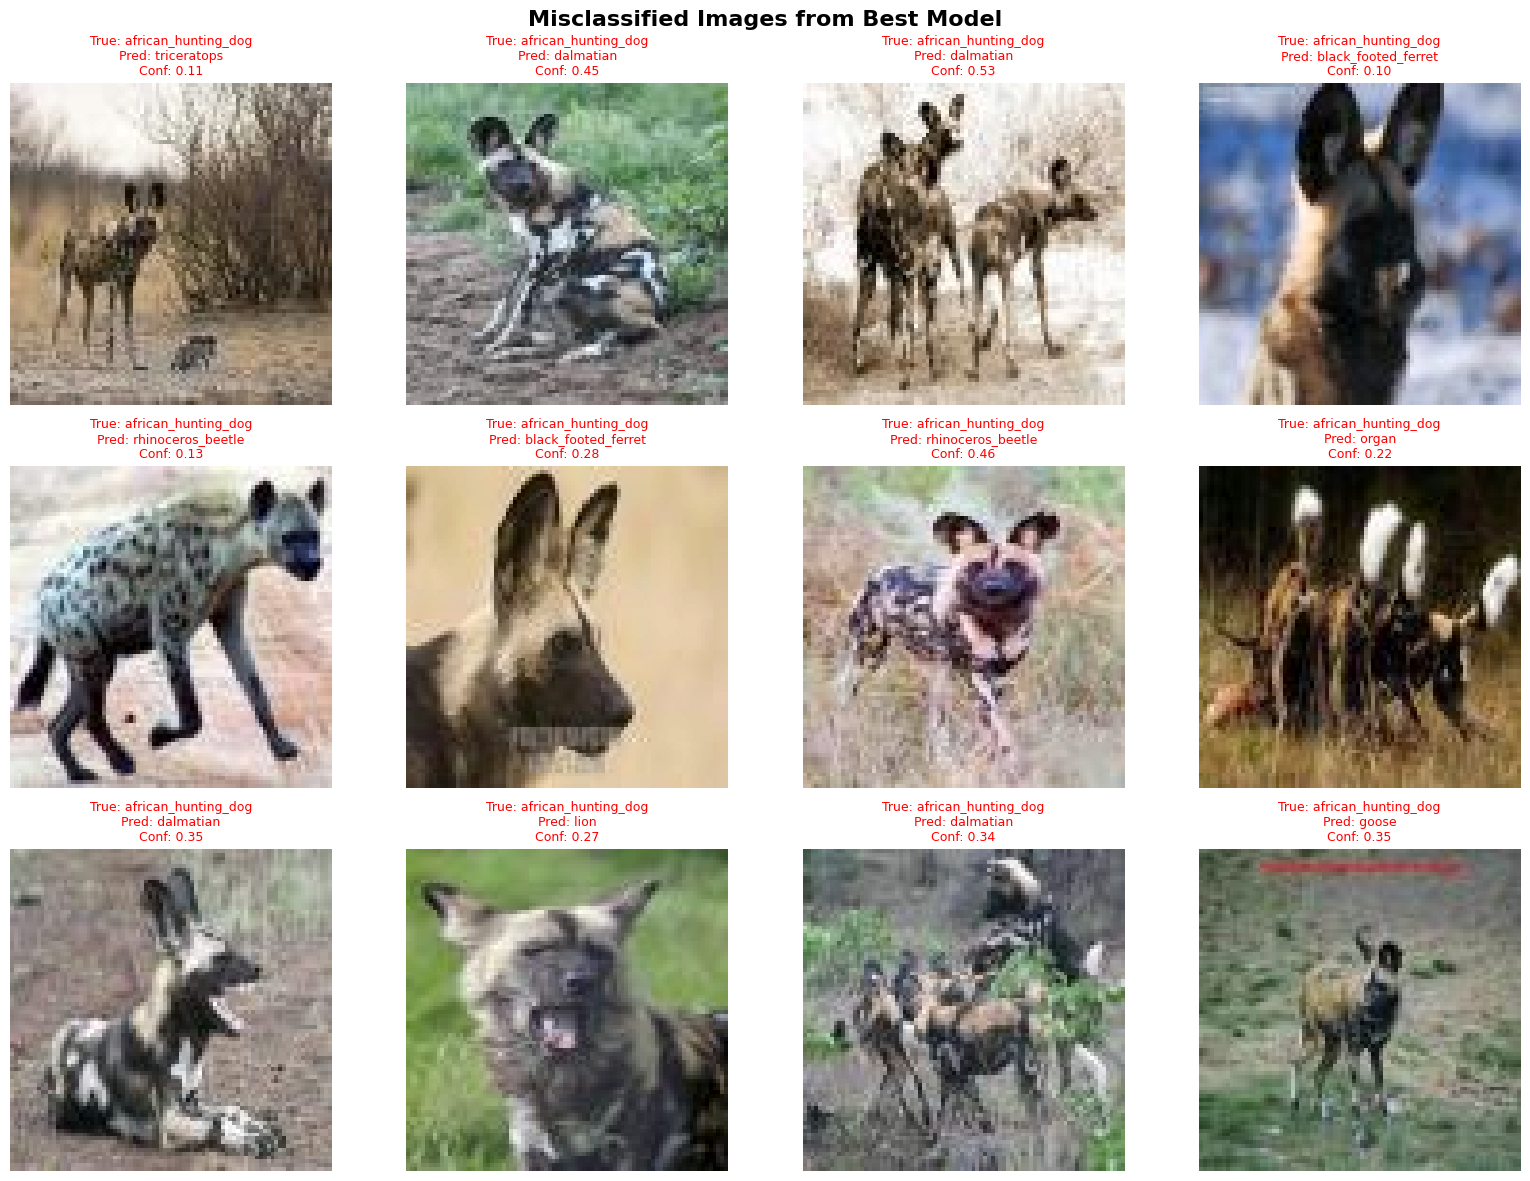


MISCLASSIFICATION ANALYSIS

Most common confusions:
  1. african_hunting_dog → dalmatian: 5 times
  2. african_hunting_dog → black_footed_ferret: 4 times
  3. african_hunting_dog → lion: 3 times
  4. african_hunting_dog → rhinoceros_beetle: 2 times
  5. african_hunting_dog → goose: 2 times

💡 Observations:
   - Look for visually similar classes being confused
   - Check if low confidence predictions (< 0.5) indicate uncertainty
   - Identify if errors are due to image quality or inherent similarity


In [96]:
# Find best model configuration
if all_results:
    test_accs_numeric = [float(r['Test Acc'].replace('%', '')) for r in all_results]
    best_config_idx = test_accs_numeric.index(max(test_accs_numeric))
    best_config_id = all_results[best_config_idx]['Config ID']
    best_config = configurations[best_config_id]

    print(f"\nAnalyzing misclassifications from: {best_config['name']}")
    print("Creating best model again...")

    # Recreate and retrain best model
    best_model = FlexibleCNN(num_classes=num_classes, config=best_config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(best_model.parameters(), lr=best_config['lr'])

    # Quick retrain (or load saved weights if you saved them)
    print("Retraining best model for misclassification analysis...")
    train_model(best_model, train_loader, val_loader, criterion, optimizer,
                best_config['epochs'], device, "Best Model (Retrain)")

    # Get misclassified images
    print("\nFinding misclassified images...")
    misclassified = get_misclassified_images(best_model, test_loader, device,
                                            class_names, num_samples=20)

    print(f"Found {len(misclassified)} misclassified images")

    # Visualize
    visualize_misclassified(misclassified, class_names, num_display=12)

    # Analyze patterns
    print("\n" + "="*70)
    print("MISCLASSIFICATION ANALYSIS")
    print("="*70)

    if misclassified:
        # Count confusion pairs
        confusion_pairs = {}
        for _, true_label, pred_label, _ in misclassified:
            pair = (class_names[true_label], class_names[pred_label])
            confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

        # Sort by frequency
        sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)

        print("\nMost common confusions:")
        for idx, ((true_cls, pred_cls), count) in enumerate(sorted_pairs[:5], 1):
            print(f"  {idx}. {true_cls} → {pred_cls}: {count} times")

        print("\n💡 Observations:")
        print("   - Look for visually similar classes being confused")
        print("   - Check if low confidence predictions (< 0.5) indicate uncertainty")
        print("   - Identify if errors are due to image quality or inherent similarity")

#SUMMARY

In [97]:
if all_results:
    print("\n📊 EXPERIMENTAL RESULTS:")
    print("-" * 100)

    # Summary statistics
    test_accs_vals = [float(r['Test Acc'].replace('%', '')) for r in all_results]

    print(f"\n1. PERFORMANCE METRICS:")
    print(f"   • Total configurations tested: {len(all_results)}")
    print(f"   • Best test accuracy: {max(test_accs_vals):.2f}%")
    print(f"   • Worst test accuracy: {min(test_accs_vals):.2f}%")
    print(f"   • Average test accuracy: {np.mean(test_accs_vals):.2f}%")
    print(f"   • Performance range: {max(test_accs_vals) - min(test_accs_vals):.2f}%")

    print(f"\n2. KEY FINDINGS:")
    print(f"   • Dropout comparison: Based on configs 2-3 comparison")
    print(f"   • Pooling contribution: Configs 3-4 analysis")
    print(f"   • FC Layer contribution: Configs 3-5 analysis")
    print(f"   • Epoch contribution: Configs 6-7 analysis")
    print(f"   • ConvLayer contribution Deep vs Very Deep: Configs 6-8 analysis")

    # Find where performance plateaus
    print(f"\n3. PERFORMANCE TRENDS:")

    # Group by conv depth
    depth_perf = {
        '1 conv': [r for r in all_results if '[64]' in r['Conv Layers']],
        '2 conv': [r for r in all_results if r['Conv Layers'].count(',') == 1],
        '3 conv': [r for r in all_results if r['Conv Layers'].count(',') == 2],
        '4 conv': [r for r in all_results if r['Conv Layers'].count(',') == 3]
    }

    print("   Conv Layer Depth Analysis:")
    for depth, configs in depth_perf.items():
        if configs:
            accs = [float(c['Test Acc'].replace('%', '')) for c in configs]
            print(f"      • {depth}: Avg = {np.mean(accs):.2f}% (n={len(accs)})")

    print(f"\n4. OVERFITTING ANALYSIS:")
    for result in all_results:
        train_acc = float(result['Final Train Acc'].replace('%', ''))
        val_acc = float(result['Final Val Acc'].replace('%', ''))
        gap = train_acc - val_acc

        if gap > 10:
            print(f"   ⚠️  {result['Name']}: Train-Val gap = {gap:.2f}% (possible overfitting)")

    print(f"\n5. EFFICIENCY:")
    print("   Parameter count vs Performance:")
    for result in all_results[:3]:  # Show top 3
        print(f"   • {result['Name']}: {result['Total Params']:,} params → {result['Test Acc']}")

    print(f"\n6. RECOMMENDATIONS FOR PART B:")
    best_config_name = all_results[best_config_idx]['Name']
    best_test_acc = all_results[best_config_idx]['Test Acc']
    print(f"   ✓ Using: {best_config_name}")
    print(f"   ✓ Test Accuracy: {best_test_acc}")
    print(f"   ✓ This model will be used for occlusion sensitivity analysis")

    print("\n" + "="*100)
    print("✓ PART A COMPLETED - Proceed to PART B for model interpretability")
    print("="*100)

else:
    print("\n⚠️  No results available. Please run the experiments in Cell 10 first.")


📊 EXPERIMENTAL RESULTS:
----------------------------------------------------------------------------------------------------

1. PERFORMANCE METRICS:
   • Total configurations tested: 6
   • Best test accuracy: 39.70%
   • Worst test accuracy: 3.03%
   • Average test accuracy: 16.49%
   • Performance range: 36.67%

2. KEY FINDINGS:
   • Dropout comparison: Based on configs 2-3 comparison
   • Pooling contribution: Configs 3-4 analysis
   • FC Layer contribution: Configs 3-5 analysis
   • Epoch contribution: Configs 6-7 analysis
   • ConvLayer contribution Deep vs Very Deep: Configs 6-8 analysis

3. PERFORMANCE TRENDS:
   Conv Layer Depth Analysis:
      • 1 conv: Avg = 3.03% (n=1)
      • 2 conv: Avg = 14.05% (n=4)
      • 3 conv: Avg = 39.70% (n=1)

4. OVERFITTING ANALYSIS:

5. EFFICIENCY:
   Parameter count vs Performance:
   • Shallow (1 Conv layer only): 14,456,993 params → 3.03%
   • Baseline (2 Conv, 1 FC) With less Dropout: 3,636,641 params → 3.03%
   • Baseline (2 Conv, 1 FC):

PART B: OCCLUSION SENSITIVITY

In [98]:
def apply_occlusion(image, center_i, center_j, window_size):
    """
    Apply gray occlusion patch to image

    Args:
        image: Input tensor [C, H, W]
        center_i: Row center of occlusion window
        center_j: Column center of occlusion window
        window_size: Size of square occlusion window (N×N)

    Returns:
        Occluded image
    """
    occluded = image.clone()

    # Calculate window boundaries
    half_window = window_size // 2

    i_start = max(0, center_i - half_window)
    i_end = min(image.shape[1], center_i + half_window)
    j_start = max(0, center_j - half_window)
    j_end = min(image.shape[2], center_j + half_window)

    # Apply gray occlusion (0.5 in normalized space)
    # This corresponds to mid-gray after normalization
    occluded[:, i_start:i_end, j_start:j_end] = 0.0

    return occluded

In [99]:
def occlusion_sensitivity(model, image, true_class, window_size, stride, device):
    """
    Perform occlusion sensitivity analysis on a single image

    Args:
        model: Trained CNN model
        image: Input image tensor [C, H, W]
        true_class: Ground truth class index
        window_size: Size of occlusion window (N×N)
        stride: Step size for sliding window
        device: CPU or GPU

    Returns:
        confidence_map: 2D array of confidence values
        original_confidence: Confidence before occlusion
    """
    model.eval()

    _, height, width = image.shape

    # Get original prediction confidence
    with torch.no_grad():
        original_output = model(image.unsqueeze(0).to(device))
        original_prob = F.softmax(original_output, dim=1)
        original_confidence = original_prob[0, true_class].item()

    # Initialize confidence map
    confidence_map = np.zeros((height, width))

    # Slide occlusion window across image
    print(f"Running occlusion analysis (window={window_size}, stride={stride})...")

    positions = []
    for i in range(0, height, stride):
        for j in range(0, width, stride):
            positions.append((i, j))

    for i, j in tqdm(positions, desc="Occlusion", leave=False):
        # Apply occlusion
        occluded_img = apply_occlusion(image, i, j, window_size)

        # Get prediction
        with torch.no_grad():
            output = model(occluded_img.unsqueeze(0).to(device))
            prob = F.softmax(output, dim=1)
            confidence = prob[0, true_class].item()

        # Store confidence at this position
        # Fill the entire window region with this confidence value
        half_window = window_size // 2
        i_start = max(0, i - half_window)
        i_end = min(height, i + half_window)
        j_start = max(0, j - half_window)
        j_end = min(width, j + half_window)

        confidence_map[i_start:i_end, j_start:j_end] = confidence

    return confidence_map, original_confidence

In [100]:
def visualize_occlusion_result(image, confidence_map, original_confidence,
                               true_class, predicted_class, class_names):
    """
    Visualize occlusion sensitivity results

    Shows:
    1. Original image
    2. Confidence heatmap
    3. Overlay
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Denormalize image for display
    img_display = image.numpy().transpose(1, 2, 0)
    mean = np.array(MEAN)
    std = np.array(STD)
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    # 1. Original image
    axes[0].imshow(img_display)
    axes[0].set_title(f'Original Image\nTrue: {class_names[true_class]}\n'
                     f'Pred: {class_names[predicted_class]}\n'
                     f'Confidence: {original_confidence:.3f}',
                     fontsize=11, fontweight='bold')
    axes[0].axis('off')

    # 2. Confidence heatmap
    im = axes[1].imshow(confidence_map, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title(f'Occlusion Sensitivity Heatmap\n'
                     f'(Red = High importance, Blue = Low importance)',
                     fontsize=11, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # 3. Overlay
    axes[2].imshow(img_display)
    axes[2].imshow(confidence_map, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[2].set_title('Overlay\n(Important regions highlighted)',
                     fontsize=11, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()

    return fig

In [101]:
# Parameters for occlusion
WINDOW_SIZE = 5  # Size of occlusion patch (N×N)
STRIDE = 2  # Step size for sliding window (smaller = more detailed but slower)

print("PART B: OCCLUSION SENSITIVITY ANALYSIS")
print(f"\nParameters:")
print(f"  Occlusion window size: {WINDOW_SIZE}×{WINDOW_SIZE} pixels")
print(f"  Stride: {STRIDE} pixels")
print(f"  Number of images to analyze: 10")
print(f"\nInterpretation:")
print(f"  • RED regions: Model confidence drops when occluded (important for classification)")
print(f"  • BLUE regions: Model confidence stable when occluded (less important)")
print(f"  • This reveals if model focuses on object or background/context")

PART B: OCCLUSION SENSITIVITY ANALYSIS

Parameters:
  Occlusion window size: 5×5 pixels
  Stride: 2 pixels
  Number of images to analyze: 10

Interpretation:
  • RED regions: Model confidence drops when occluded (important for classification)
  • BLUE regions: Model confidence stable when occluded (less important)
  • This reveals if model focuses on object or background/context


In [102]:
def select_test_images_for_occlusion(model, test_loader, device, class_names,
                                    num_images=10, criteria_confidence=0.5):
    """
    Select diverse test images for occlusion analysis

    Strategy:
    - Get correctly classified images
    - Select high confidence predictions
    - Diverse classes

    Returns:
        List of (image, true_label, predicted_label, confidence) tuples
    """
    model.eval()
    selected_images = []
    selected_classes = set()

    with torch.no_grad():
        for images, labels in test_loader:
            if len(selected_images) >= num_images:
                break

            images_dev, labels_dev = images.to(device), labels.to(device)
            outputs = model(images_dev)
            probabilities = F.softmax(outputs, dim=1)
            confidences, predicted = probabilities.max(1)

            # Find correctly classified with high confidence
            correct = predicted.eq(labels_dev)

            for idx in range(len(images)):
                if len(selected_images) >= num_images:
                    break

                if correct[idx]:  # Correctly classified
                    true_label = labels[idx].item()
                    pred_label = predicted[idx].item()
                    confidence = confidences[idx].item()

                    # Prefer diverse classes and high confidence
                    if (confidence > criteria_confidence and
                        (true_label not in selected_classes or len(selected_images) < 5)):

                        selected_images.append((
                            images[idx],
                            true_label,
                            pred_label,
                            confidence
                        ))
                        selected_classes.add(true_label)

    return selected_images

In [103]:
# Select images using best model from Part A
if all_results:
    print("\nSelecting Upto 10 test images for occlusion analysis...")
    print("Criteria: Correctly classified, high confidence, diverse classes")

    selected_test_images = select_test_images_for_occlusion(
        best_model, test_loader, device, class_names, num_images=10,criteria_confidence=0.4
    )

    print(f"\n✓ Selected {len(selected_test_images)} images")
    print("\nSelected images:")
    for idx, (img, true_label, pred_label, conf) in enumerate(selected_test_images, 1):
        print(f"  {idx}. Class: {class_names[true_label]}, Confidence: {conf:.3f}")


Selecting Upto 10 test images for occlusion analysis...
Criteria: Correctly classified, high confidence, diverse classes

✓ Selected 10 images

Selected images:
  1. Class: african_hunting_dog, Confidence: 0.510
  2. Class: african_hunting_dog, Confidence: 0.510
  3. Class: african_hunting_dog, Confidence: 0.465
  4. Class: african_hunting_dog, Confidence: 0.403
  5. Class: african_hunting_dog, Confidence: 0.567
  6. Class: black_footed_ferret, Confidence: 0.403
  7. Class: carousel, Confidence: 0.606
  8. Class: catamaran, Confidence: 0.984
  9. Class: cocktail_shaker, Confidence: 0.617
  10. Class: consomme, Confidence: 0.518


RUNNING OCCLUSION SENSITIVITY ANALYSIS
Processing 10 images...


──────────────────────────────────────────────────────────────────────
Image 1/10: african_hunting_dog (Confidence: 0.510)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


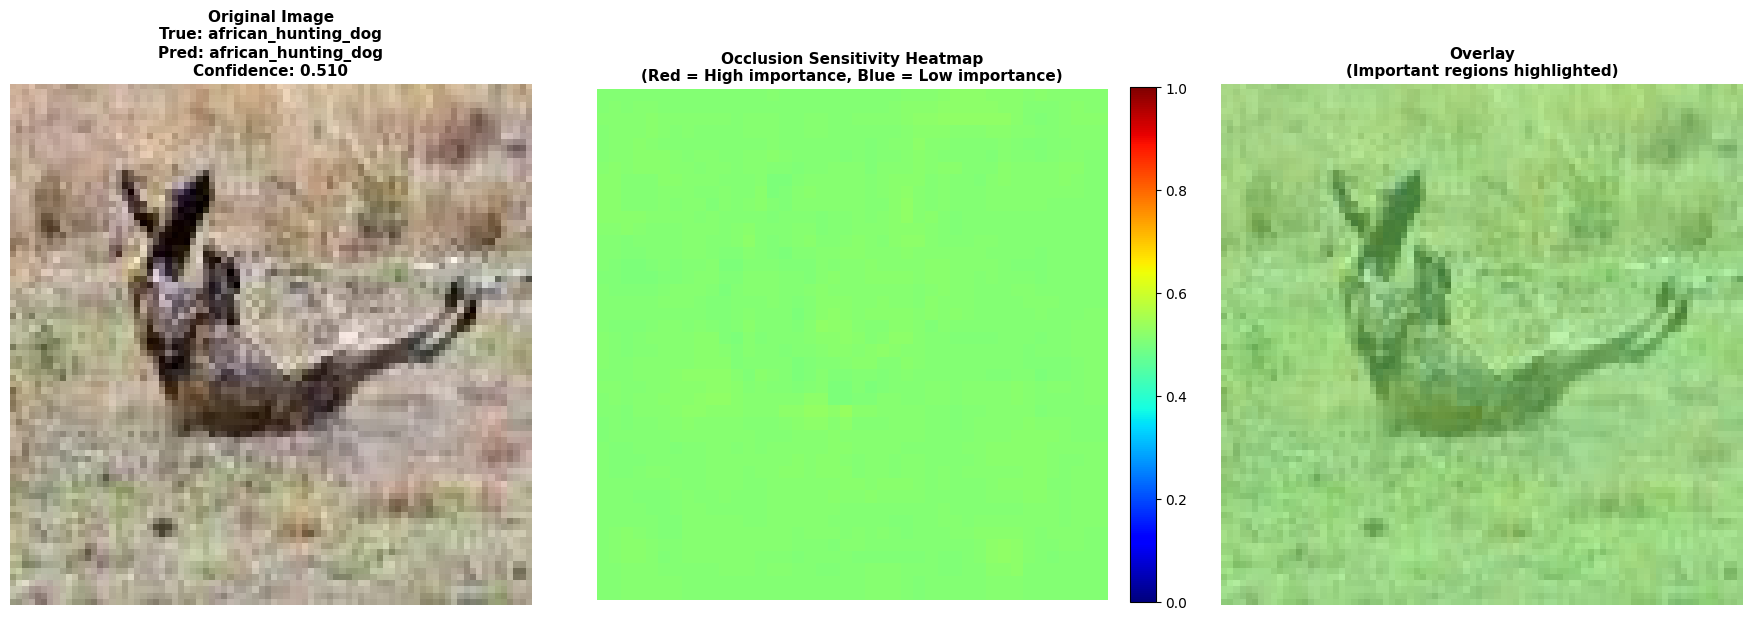

  Original confidence: 0.510
  Min confidence (max drop): 0.501
  Max confidence drop: 0.010
  ✓ Saved: part_b_occlusion_image_1.png

──────────────────────────────────────────────────────────────────────
Image 2/10: african_hunting_dog (Confidence: 0.510)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


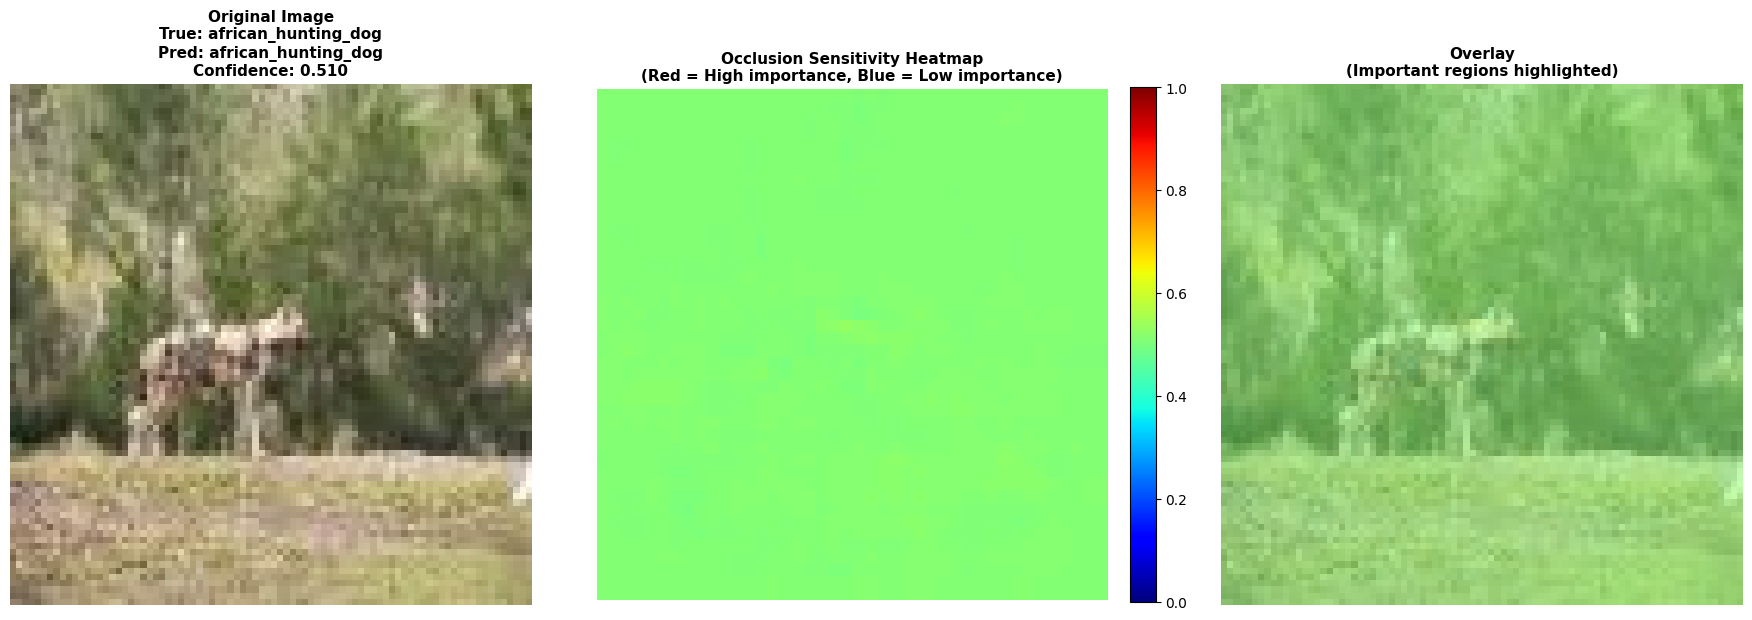

  Original confidence: 0.510
  Min confidence (max drop): 0.498
  Max confidence drop: 0.012
  ✓ Saved: part_b_occlusion_image_2.png

──────────────────────────────────────────────────────────────────────
Image 3/10: african_hunting_dog (Confidence: 0.465)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


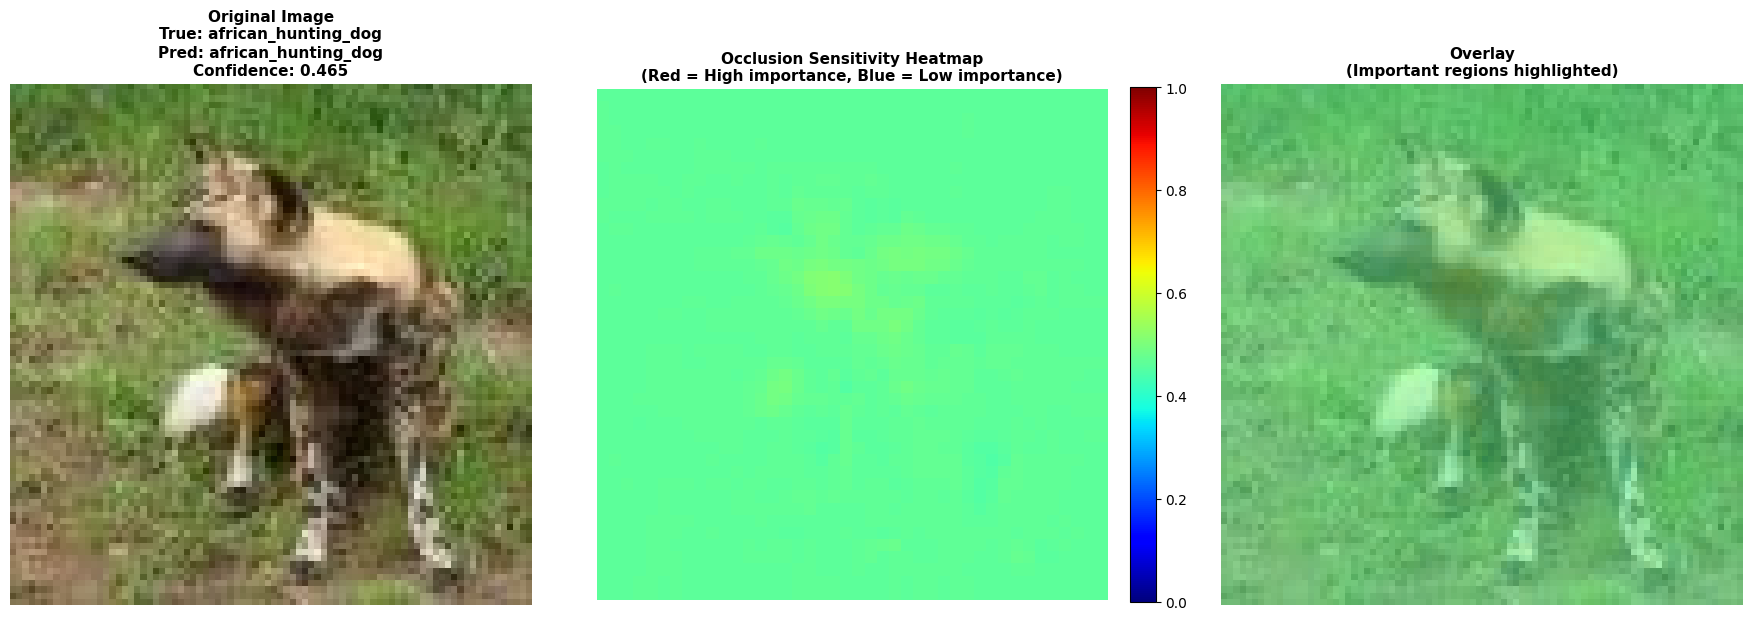

  Original confidence: 0.465
  Min confidence (max drop): 0.448
  Max confidence drop: 0.017
  ✓ Saved: part_b_occlusion_image_3.png

──────────────────────────────────────────────────────────────────────
Image 4/10: african_hunting_dog (Confidence: 0.403)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


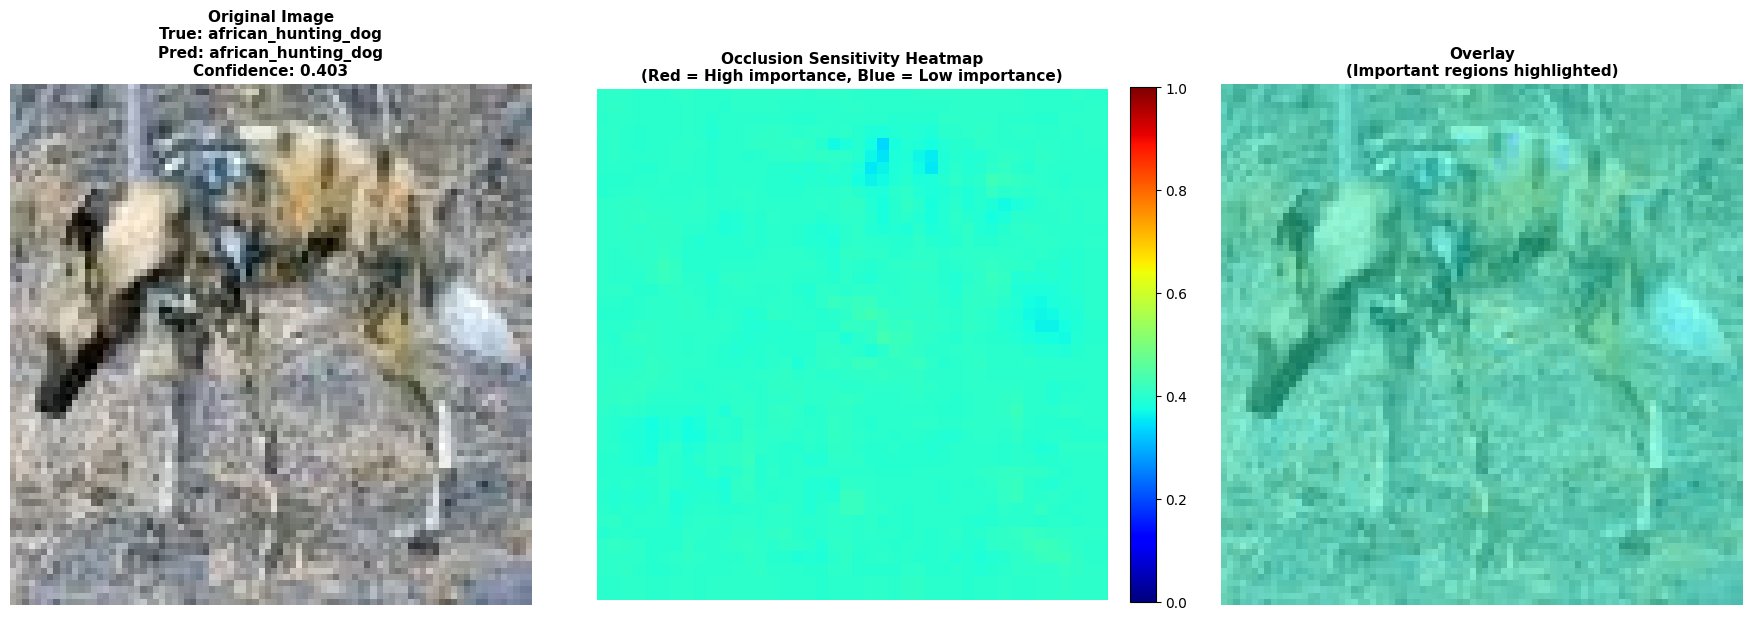

  Original confidence: 0.403
  Min confidence (max drop): 0.338
  Max confidence drop: 0.065
  ✓ Saved: part_b_occlusion_image_4.png

──────────────────────────────────────────────────────────────────────
Image 5/10: african_hunting_dog (Confidence: 0.567)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


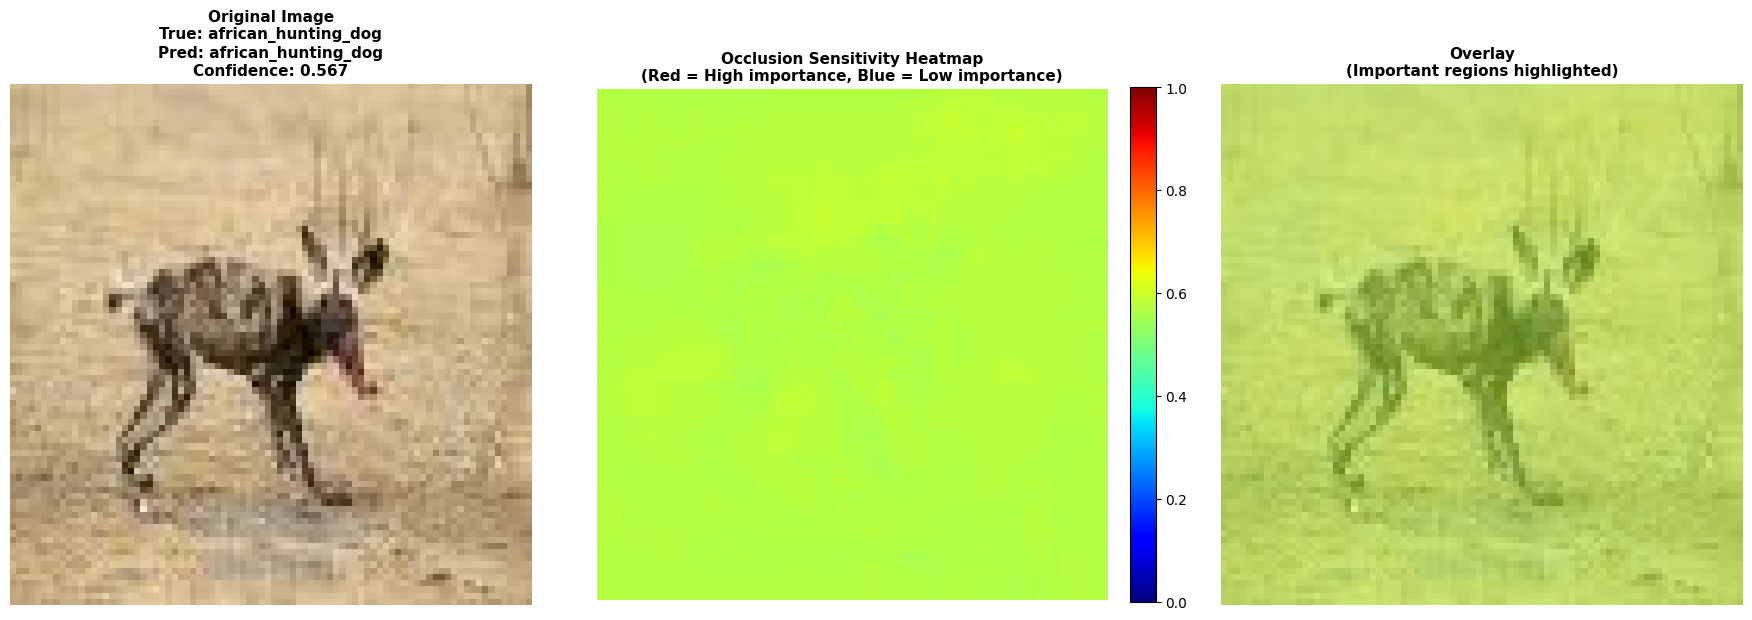

  Original confidence: 0.567
  Min confidence (max drop): 0.555
  Max confidence drop: 0.012
  ✓ Saved: part_b_occlusion_image_5.png

──────────────────────────────────────────────────────────────────────
Image 6/10: black_footed_ferret (Confidence: 0.403)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


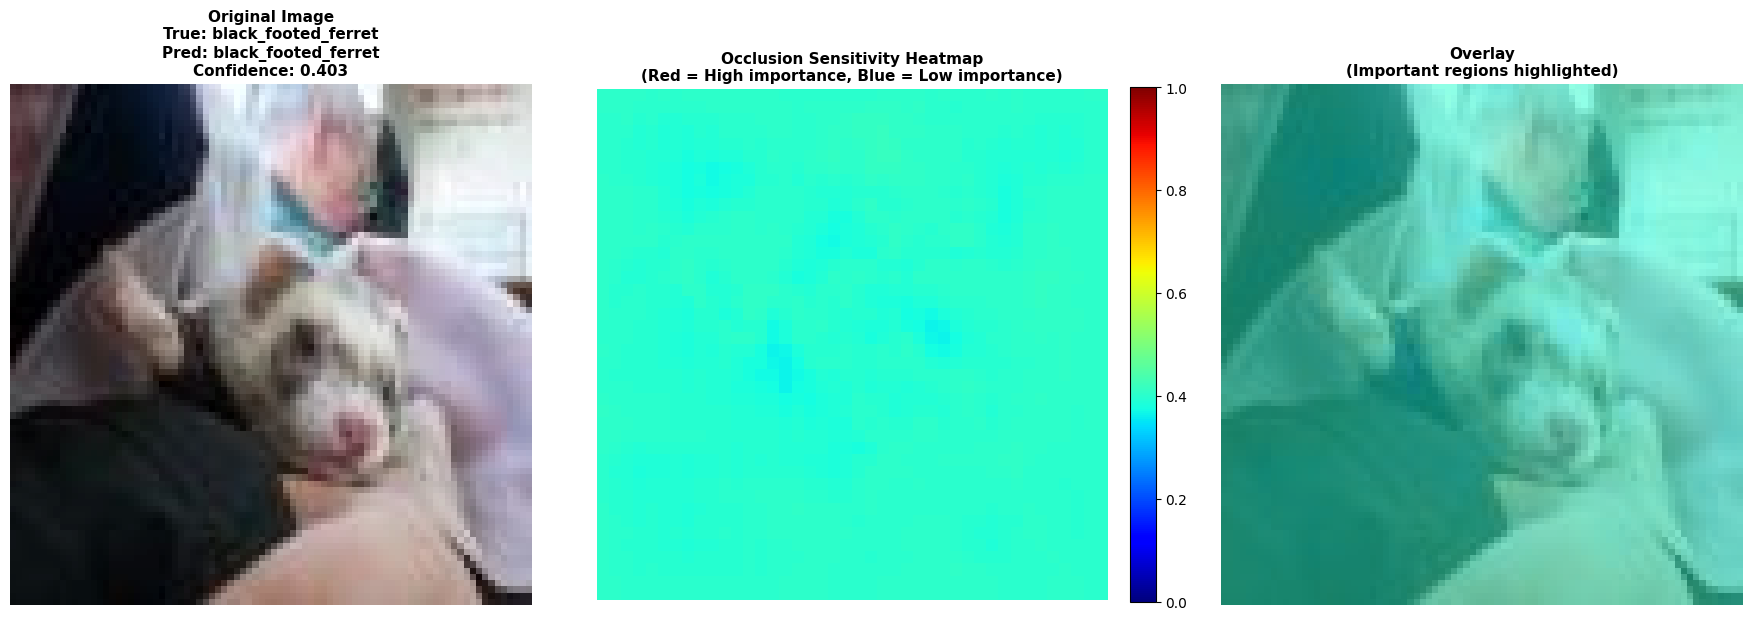

  Original confidence: 0.403
  Min confidence (max drop): 0.365
  Max confidence drop: 0.038
  ✓ Saved: part_b_occlusion_image_6.png

──────────────────────────────────────────────────────────────────────
Image 7/10: carousel (Confidence: 0.606)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


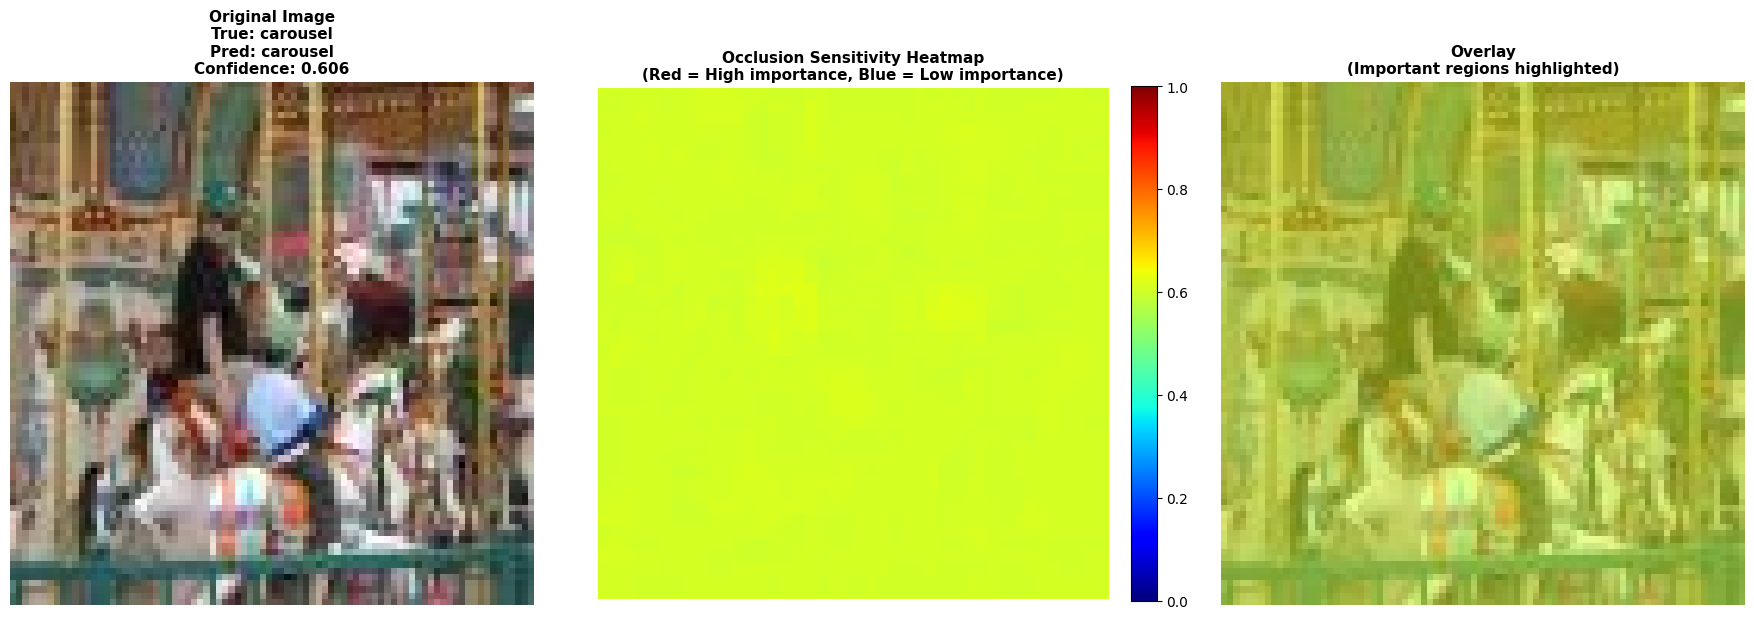

  Original confidence: 0.606
  Min confidence (max drop): 0.593
  Max confidence drop: 0.012
  ✓ Saved: part_b_occlusion_image_7.png

──────────────────────────────────────────────────────────────────────
Image 8/10: catamaran (Confidence: 0.984)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


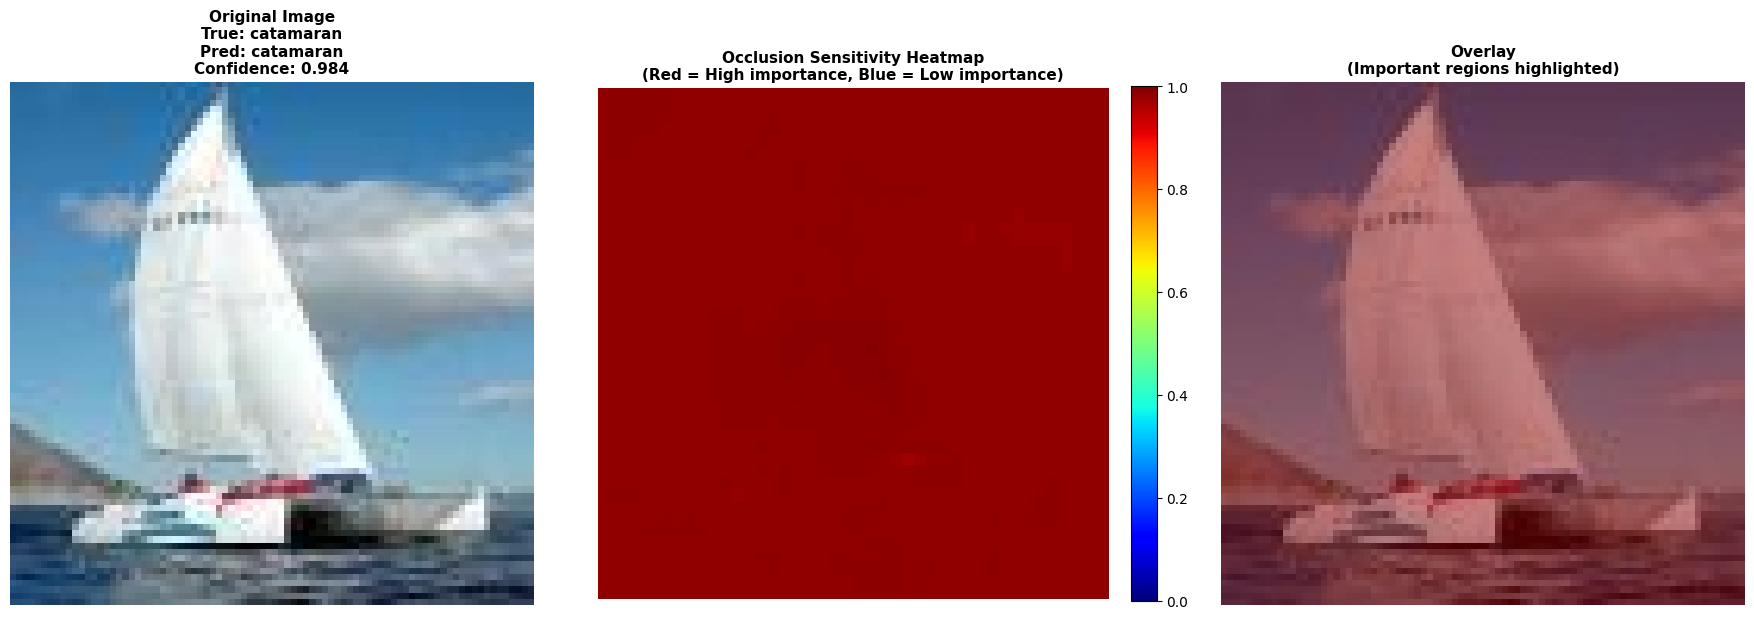

  Original confidence: 0.984
  Min confidence (max drop): 0.972
  Max confidence drop: 0.012
  ✓ Saved: part_b_occlusion_image_8.png

──────────────────────────────────────────────────────────────────────
Image 9/10: cocktail_shaker (Confidence: 0.617)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


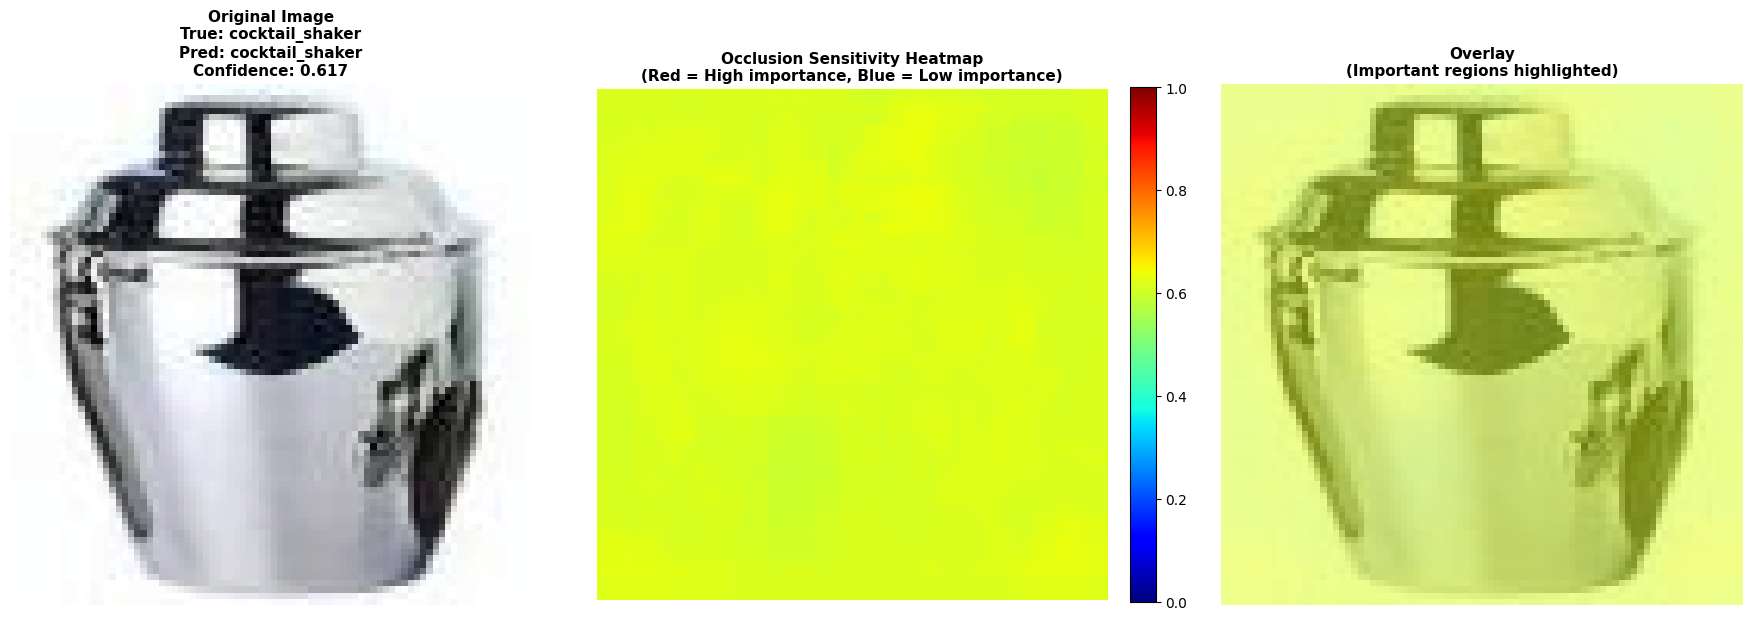

  Original confidence: 0.617
  Min confidence (max drop): 0.589
  Max confidence drop: 0.028
  ✓ Saved: part_b_occlusion_image_9.png

──────────────────────────────────────────────────────────────────────
Image 10/10: consomme (Confidence: 0.518)
──────────────────────────────────────────────────────────────────────
Running occlusion analysis (window=5, stride=2)...


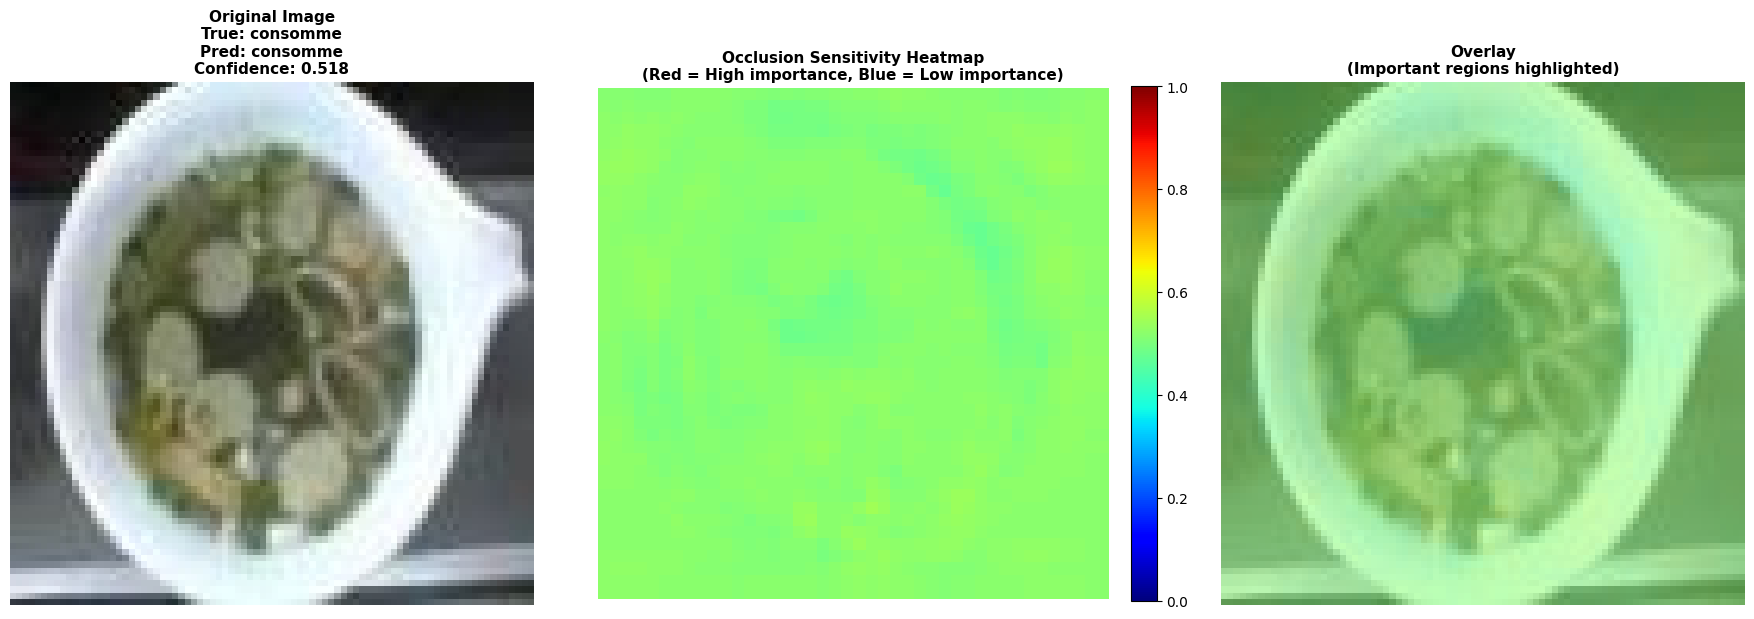

  Original confidence: 0.518
  Min confidence (max drop): 0.473
  Max confidence drop: 0.045
  ✓ Saved: part_b_occlusion_image_10.png


In [104]:
occlusion_results = []

if selected_test_images:
    print("RUNNING OCCLUSION SENSITIVITY ANALYSIS")
    print(f"Processing {len(selected_test_images)} images...\n")

    for idx, (image, true_label, pred_label, orig_conf) in enumerate(selected_test_images, 1):
        print(f"\n{'─'*70}")
        print(f"Image {idx}/{len(selected_test_images)}: {class_names[true_label]} (Confidence: {orig_conf:.3f})")
        print(f"{'─'*70}")

        # Perform occlusion analysis
        confidence_map, original_confidence = occlusion_sensitivity(
            model=best_model,
            image=image,
            true_class=true_label,
            window_size=WINDOW_SIZE,
            stride=STRIDE,
            device=device
        )

        # Visualize results
        fig = visualize_occlusion_result(
            image=image,
            confidence_map=confidence_map,
            original_confidence=original_confidence,
            true_class=true_label,
            predicted_class=pred_label,
            class_names=class_names
        )

        # Save figure
        fig.savefig(f'part_b_occlusion_image_{idx}.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Store results
        occlusion_results.append({
            'image_idx': idx,
            'true_class': class_names[true_label],
            'confidence_map': confidence_map,
            'original_confidence': original_confidence,
            'min_confidence': confidence_map.min(),
            'max_confidence': confidence_map.max(),
            'confidence_drop': original_confidence - confidence_map.min()
        })

        print(f"  Original confidence: {original_confidence:.3f}")
        print(f"  Min confidence (max drop): {confidence_map.min():.3f}")
        print(f"  Max confidence drop: {original_confidence - confidence_map.min():.3f}")
        print(f"  ✓ Saved: part_b_occlusion_image_{idx}.png")

In [105]:
if occlusion_results:
    print("\n📊 QUANTITATIVE ANALYSIS:")

    for result in occlusion_results:
        print(f"\nImage {result['image_idx']}: {result['true_class']}")
        print(f"  Original confidence: {result['original_confidence']:.3f}")
        print(f"  Minimum confidence after occlusion: {result['min_confidence']:.3f}")
        print(f"  Maximum confidence drop: {result['confidence_drop']:.3f}")

        # Interpretation
        if result['confidence_drop'] > 0.5:
            print(f"  → Strong localization: Model heavily relies on specific regions")
        elif result['confidence_drop'] > 0.3:
            print(f"  → Moderate localization: Some regions more important than others")
        else:
            print(f"  → Weak localization: Model may use distributed features or context")

    # Overall statistics
    avg_drop = np.mean([r['confidence_drop'] for r in occlusion_results])
    max_drop = max([r['confidence_drop'] for r in occlusion_results])
    min_drop = min([r['confidence_drop'] for r in occlusion_results])

    print("\n" + "─"*70)
    print("OVERALL STATISTICS:")
    print(f"  Average confidence drop: {avg_drop:.3f}")
    print(f"  Maximum confidence drop: {max_drop:.3f}")
    print(f"  Minimum confidence drop: {min_drop:.3f}")



📊 QUANTITATIVE ANALYSIS:

Image 1: african_hunting_dog
  Original confidence: 0.510
  Minimum confidence after occlusion: 0.501
  Maximum confidence drop: 0.010
  → Weak localization: Model may use distributed features or context

Image 2: african_hunting_dog
  Original confidence: 0.510
  Minimum confidence after occlusion: 0.498
  Maximum confidence drop: 0.012
  → Weak localization: Model may use distributed features or context

Image 3: african_hunting_dog
  Original confidence: 0.465
  Minimum confidence after occlusion: 0.448
  Maximum confidence drop: 0.017
  → Weak localization: Model may use distributed features or context

Image 4: african_hunting_dog
  Original confidence: 0.403
  Minimum confidence after occlusion: 0.338
  Maximum confidence drop: 0.065
  → Weak localization: Model may use distributed features or context

Image 5: african_hunting_dog
  Original confidence: 0.567
  Minimum confidence after occlusion: 0.555
  Maximum confidence drop: 0.012
  → Weak localizat

SUMMARY

In [106]:
if occlusion_results:
    print("\n📊 OCCLUSION SENSITIVITY ANALYSIS SUMMARY:")
    print("-" * 100)

    print(f"\n1. EXPERIMENT SETUP:")
    print(f"   • Model used: {best_config['name']}")
    print(f"   • Number of images analyzed: {len(occlusion_results)}")
    print(f"   • Occlusion window size: {WINDOW_SIZE}×{WINDOW_SIZE} pixels")
    print(f"   • Stride: {STRIDE} pixels")
    print(f"   • Analysis positions per image: {(84//STRIDE) * (84//STRIDE)}")

    print(f"\n2. QUANTITATIVE FINDINGS:")
    avg_original_conf = np.mean([r['original_confidence'] for r in occlusion_results])
    avg_min_conf = np.mean([r['min_confidence'] for r in occlusion_results])
    avg_drop = np.mean([r['confidence_drop'] for r in occlusion_results])

    print(f"   • Average original confidence: {avg_original_conf:.3f}")
    print(f"   • Average minimum confidence: {avg_min_conf:.3f}")
    print(f"   • Average confidence drop: {avg_drop:.3f}")

    # Classify localization strength
    if avg_drop > 0.5:
        localization = "STRONG - Model shows clear spatial attention"
    elif avg_drop > 0.3:
        localization = "MODERATE - Model uses some spatial features"
    else:
        localization = "WEAK - Model may rely on distributed/contextual features"

    print(f"   • Localization strength: {localization}")

    print(f"\n5. VISUALIZATION OUTPUTS:")
    print(f"   Generated files:")
    for i in range(1, len(occlusion_results) + 1):
        print(f"   • part_b_occlusion_image_{i}.png")

else:
    print("\n⚠️  No occlusion results available. ")


📊 OCCLUSION SENSITIVITY ANALYSIS SUMMARY:
----------------------------------------------------------------------------------------------------

1. EXPERIMENT SETUP:
   • Model used: Balanced Architecture
   • Number of images analyzed: 10
   • Occlusion window size: 5×5 pixels
   • Stride: 2 pixels
   • Analysis positions per image: 1764

2. QUANTITATIVE FINDINGS:
   • Average original confidence: 0.558
   • Average minimum confidence: 0.533
   • Average confidence drop: 0.025
   • Localization strength: WEAK - Model may rely on distributed/contextual features

5. VISUALIZATION OUTPUTS:
   Generated files:
   • part_b_occlusion_image_1.png
   • part_b_occlusion_image_2.png
   • part_b_occlusion_image_3.png
   • part_b_occlusion_image_4.png
   • part_b_occlusion_image_5.png
   • part_b_occlusion_image_6.png
   • part_b_occlusion_image_7.png
   • part_b_occlusion_image_8.png
   • part_b_occlusion_image_9.png
   • part_b_occlusion_image_10.png
